# Mount


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 1: Import semua library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import os
import glob

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler, RobustScaler

# Untuk Random Forest
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
input_folder = '/content/drive/MyDrive/tga_anisa/'

# Combine Data


In [4]:
if not os.path.exists(input_folder):
    print(f"❌ Folder tidak ditemukan: {input_folder}")
    print("Pastikan path benar dan Drive sudah di-mount.")
else:
    # 4. Ambil semua file CSV
    all_files = glob.glob(os.path.join(input_folder, "*.csv"))
    print(f"✅ Ditemukan {len(all_files)} file CSV.")

    # 5. Baca dan gabungkan semua file
    df_list = []
    for file in all_files:
        temp_df = pd.read_csv(file)
        temp_df['source_file'] = os.path.basename(file)   # opsional: lacak asal file
        df_list.append(temp_df)

    df = pd.concat(df_list, ignore_index=True)
    print(f"📊 Total data setelah digabung: {df.shape[0]} baris x {df.shape[1]} kolom")

    # 6. Bersihkan kolom kosong (misal: kolom hasil koma ganda seperti ",,label")
    # Hapus kolom yang semua nilainya NaN
    df = df.dropna(axis=1, how='all')
    # Hapus kolom bernama 'Unnamed: ...' yang muncul dari koma berlebih
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # 7. Urutkan berdasarkan timestamp (prioritas: epoch_ms -> ts_millis -> date+time)
    if 'epoch_ms' in df.columns:
        df = df.sort_values(by='epoch_ms').reset_index(drop=True)
        print("📈 Data diurutkan berdasarkan kolom 'epoch_ms'.")
    elif 'ts_millis' in df.columns:
        df = df.sort_values(by='ts_millis').reset_index(drop=True)
        print("📈 Data diurutkan berdasarkan kolom 'ts_millis'.")
    elif 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
        df = df.sort_values(by='datetime').reset_index(drop=True)
        print("📈 Data diurutkan berdasarkan gabungan 'date' + 'time'.")
    else:
        print("⚠️ Tidak ada kolom waktu yang dikenali. Data tidak diurutkan.")

    # 8. Tampilkan cuplikan hasil
    print("\n🔍 5 baris pertama setelah penggabungan & pengurutan:")
    display(df.head())

    # 9. Tampilkan informasi kolom
    print("\n📋 Tipe data setiap kolom:")
    print(df.dtypes)

✅ Ditemukan 21 file CSV.
📊 Total data setelah digabung: 28054 baris x 22 kolom
📈 Data diurutkan berdasarkan kolom 'epoch_ms'.

🔍 5 baris pertama setelah penggabungan & pengurutan:


,subject_id,nama,date,time,epoch_ms,ts_millis,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,gx2,gy2,gz2,label,source_file
0,1,alifi,2026-05-20,17:39:01.130000,1.182281e+09,786130.0,0.97583,-0.10889,0.47021,4.557,2.489,0.473,0.90381,-0.50586,0.00171,2.817,-1.115,-0.015,ergonomis,gabungan_mpu_alifi.csv
1,1,alifi,2026-05-20,17:39:01.530000,1.182281e+09,785530.0,0.93384,-0.10181,0.55029,6.504,-21.641,7.527,0.87378,-0.54907,-0.00513,12.595,6.985,-3.611,ergonomis,gabungan_mpu_alifi.csv
2,1,alifi,2026-05-20,17:39:01.730000,1.182281e+09,785730.0,0.94409,-0.10620,0.52881,5.840,-14.130,4.130,0.86182,-0.52759,0.08643,7.145,-11.137,-5.061,ergonomis,gabungan_mpu_alifi.csv
3,1,alifi,2026-05-20,17:39:01.930000,1.182281e+09,785930.0,0.95752,-0.11206,0.49219,-1.840,-1.802,-1.099,0.89526,-0.50391,0.04443,6.229,-1.374,-2.267,ergonomis,gabungan_mpu_alifi.csv
4,1,alifi,2026-05-20,17:39:02.020000,1.182281e+09,787020.0,0.94922,-0.08813,0.50122,-4.397,2.756,-3.275,0.89209,-0.50220,0.01270,-3.580,5.053,-0.489,ergonomis,gabungan_mpu_alifi.csv



📋 Tipe data setiap kolom:
subject_id       int64
nama            object
date            object
time            object
epoch_ms       float64
ts_millis      float64
ax1            float64
ay1            float64
az1            float64
gx1            float64
gy1            float64
gz1            float64
ax2            float64
ay2            float64
az2            float64
gx2            float64
gy2            float64
gz2            float64
label           object
source_file     object
dtype: object


 # EDA

In [5]:
# Cell EDA 1: Informasi umum dataset
print("="*50)
print("1. INFORMASI UMUM DATASET")
print("="*50)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\nNama kolom:")
print(df.columns.tolist())

print("\n" + "="*50)
print("2. STATISTIK DESKRIPTIF (KOLOM NUMERIK)")
print("="*50)
display(df.describe())

print("\n" + "="*50)
print("3. STATISTIK KOLOM KATEGORIK")
print("="*50)
display(df.describe(include=['object']))

1. INFORMASI UMUM DATASET
Jumlah baris: 28054
Jumlah kolom: 20

Nama kolom:
['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'label', 'source_file']

2. STATISTIK DESKRIPTIF (KOLOM NUMERIK)


,subject_id,epoch_ms,ts_millis,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,az2,gx2,gy2,gz2
count,28054.000000,2.805400e+04,2.805400e+04,28054.000000,28040.000000,28052.000000,28008.000000,28020.000000,27964.000000,28054.000000,28033.000000,28043.000000,28019.000000,27987.000000,28008.000000
mean,11.565267,1.769778e+09,6.560003e+05,0.850136,0.021467,0.527774,-0.699900,1.089682,-0.314907,0.949841,-0.007217,0.252602,-1.192238,0.674596,0.880955
std,6.712887,4.560001e+08,3.452609e+05,0.181415,0.121071,0.291488,4.404842,5.341845,2.541103,0.063218,0.256722,0.275721,4.694517,4.144289,2.619525
min,1.000000,1.182281e+09,1.254370e+05,-0.270260,-0.435790,-0.270750,-95.435000,-96.817000,-110.611000,-0.741210,-0.749760,-0.907230,-125.450000,-89.458000,-73.710000
25%,6.000000,1.350132e+09,3.808632e+05,0.784910,-0.064700,0.271730,-1.939000,0.176000,-0.893000,0.905760,-0.133790,0.064450,-2.168000,-0.046000,0.265250
50%,11.000000,1.437638e+09,5.195665e+05,0.911380,0.030030,0.542720,-0.557000,1.244000,-0.344000,0.954830,0.020510,0.217290,-1.153000,0.618000,0.779000
75%,17.000000,2.210786e+09,9.434045e+05,0.974120,0.109380,0.757140,0.618000,2.099000,0.229000,1.003660,0.207030,0.425660,-0.183000,1.366000,1.481000
max,23.000000,2.301570e+09,1.652398e+06,1.263430,1.615230,1.122800,170.595000,243.275000,78.969000,1.516850,0.540040,1.065190,109.939000,116.458000,70.786000



3. STATISTIK KOLOM KATEGORIK


,nama,date,time,label,source_file
count,28054,28054,28054,28054,28054
unique,21,6,28045,2,21
top,alifi,2026-06-01,17:53:24.444000,ergonomis,gabungan_mpu_alifi.csv
freq,3560,11710,2,14678,3560


## Missing Values

MISSING VALUES PER KOLOM


,Missing Values,Persentase (%)
gz1,90,0.320810
gy2,67,0.238825
gx1,46,0.163969
gz2,46,0.163969
gx2,35,0.124759
gy1,34,0.121195
ay2,21,0.074856
ay1,14,0.049904
az2,11,0.039210
az1,2,0.007129



⚠️ Ada missing values. Perlu ditangani pada tahap cleaning.


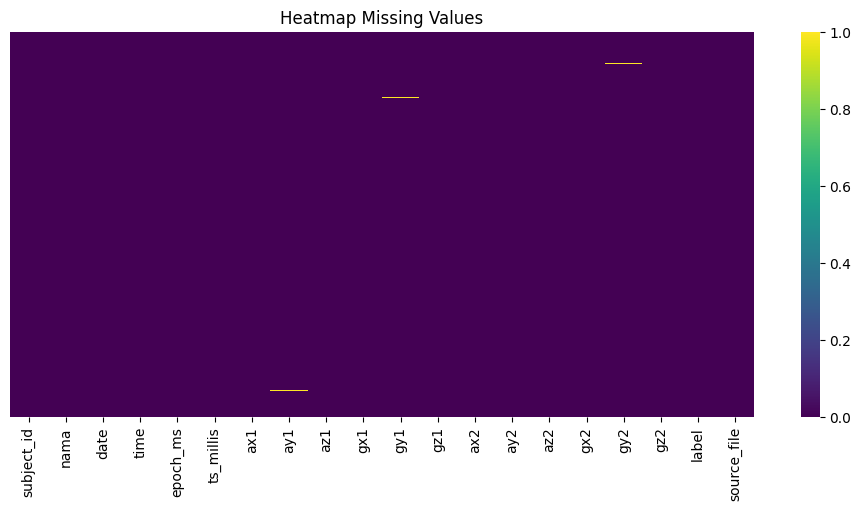

In [6]:
# Cell EDA 2: Analisis missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Persentase (%)': missing_percent
}).sort_values(by='Persentase (%)', ascending=False)

print("="*50)
print("MISSING VALUES PER KOLOM")
print("="*50)
display(missing_table[missing_table['Missing Values'] > 0])

if missing_table['Missing Values'].sum() == 0:
    print("\n✅ Tidak ada missing values dalam dataset.")
else:
    print("\n⚠️ Ada missing values. Perlu ditangani pada tahap cleaning.")

# Visualisasi missing values heatmap (jika ada)
if missing_table['Missing Values'].sum() > 0:
    plt.figure(figsize=(12, 5))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
    plt.title('Heatmap Missing Values')
    plt.show()

## Distribusi dan Outlier

Kolom numerik yang ditemukan: ['subject_id', 'epoch_ms', 'ts_millis', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2']
Label unik: ['ergonomis' 'non-ergonomis']

--- Analisis untuk label: ergonomis ---


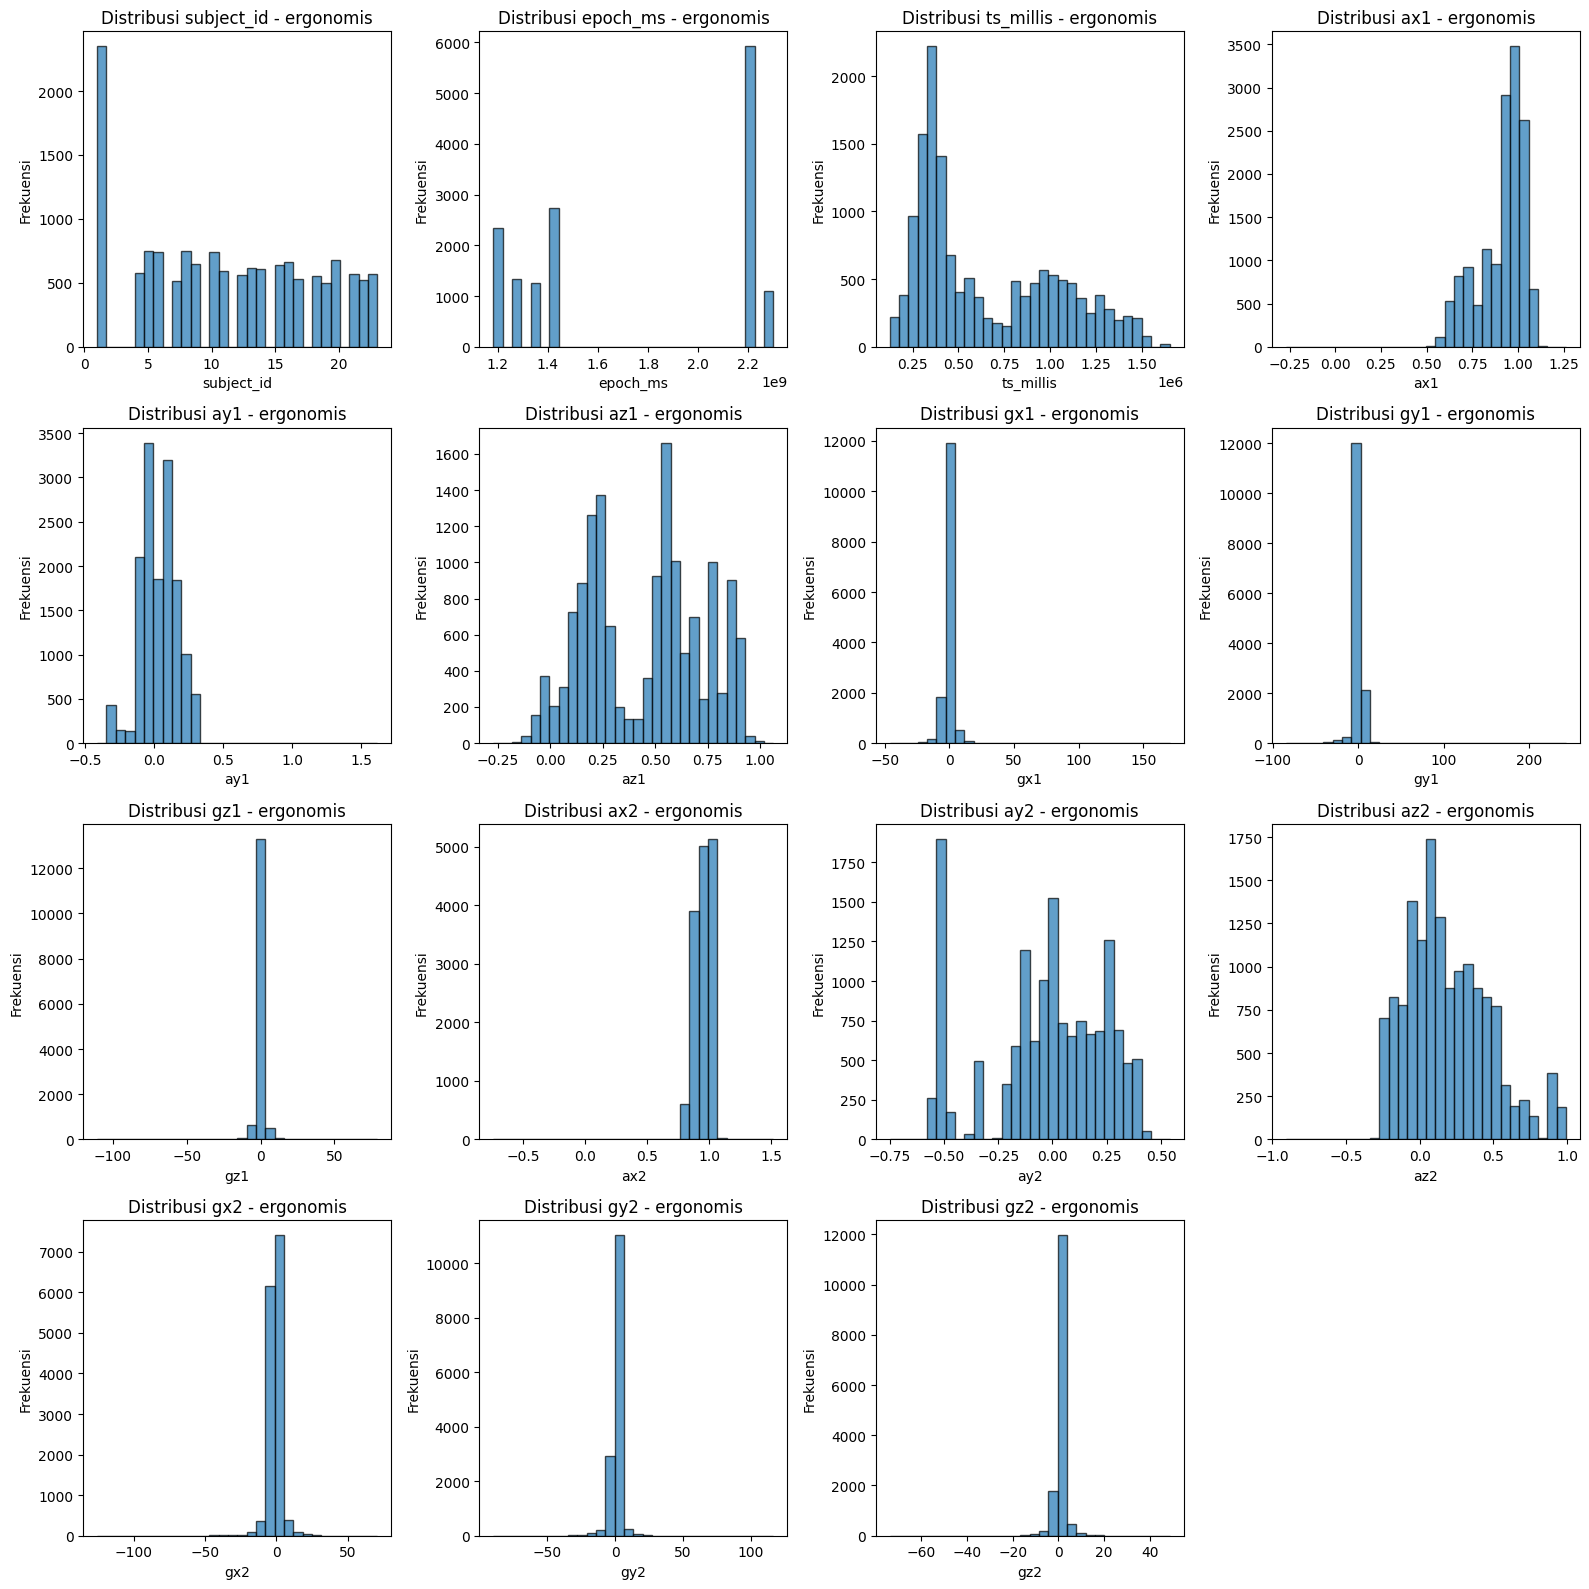

Jumlah outlier pada kolom 'ax1' untuk label 'ergonomis': 192
Jumlah outlier pada kolom 'ay1' untuk label 'ergonomis': 12
Jumlah outlier pada kolom 'gx1' untuk label 'ergonomis': 1310
Jumlah outlier pada kolom 'gy1' untuk label 'ergonomis': 1566
Jumlah outlier pada kolom 'gz1' untuk label 'ergonomis': 1932
Jumlah outlier pada kolom 'ax2' untuk label 'ergonomis': 9
Jumlah outlier pada kolom 'ay2' untuk label 'ergonomis': 1
Jumlah outlier pada kolom 'az2' untuk label 'ergonomis': 2
Jumlah outlier pada kolom 'gx2' untuk label 'ergonomis': 1928
Jumlah outlier pada kolom 'gy2' untuk label 'ergonomis': 1979
Jumlah outlier pada kolom 'gz2' untuk label 'ergonomis': 1611


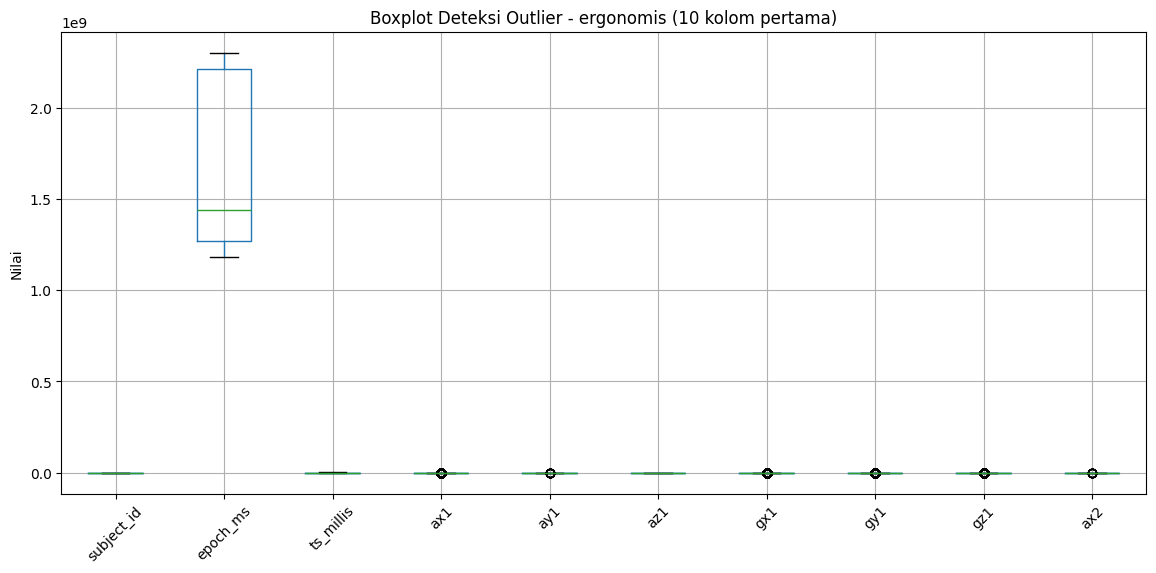

Ringkasan outlier per kolom untuk label 'ergonomis':
  subject_id: 0
  epoch_ms: 0
  ts_millis: 0
  ax1: 192
  ay1: 12
  az1: 0
  gx1: 1310
  gy1: 1566
  gz1: 1932
  ax2: 9
  ay2: 1
  az2: 2
  gx2: 1928
  gy2: 1979
  gz2: 1611

--- Analisis untuk label: non-ergonomis ---


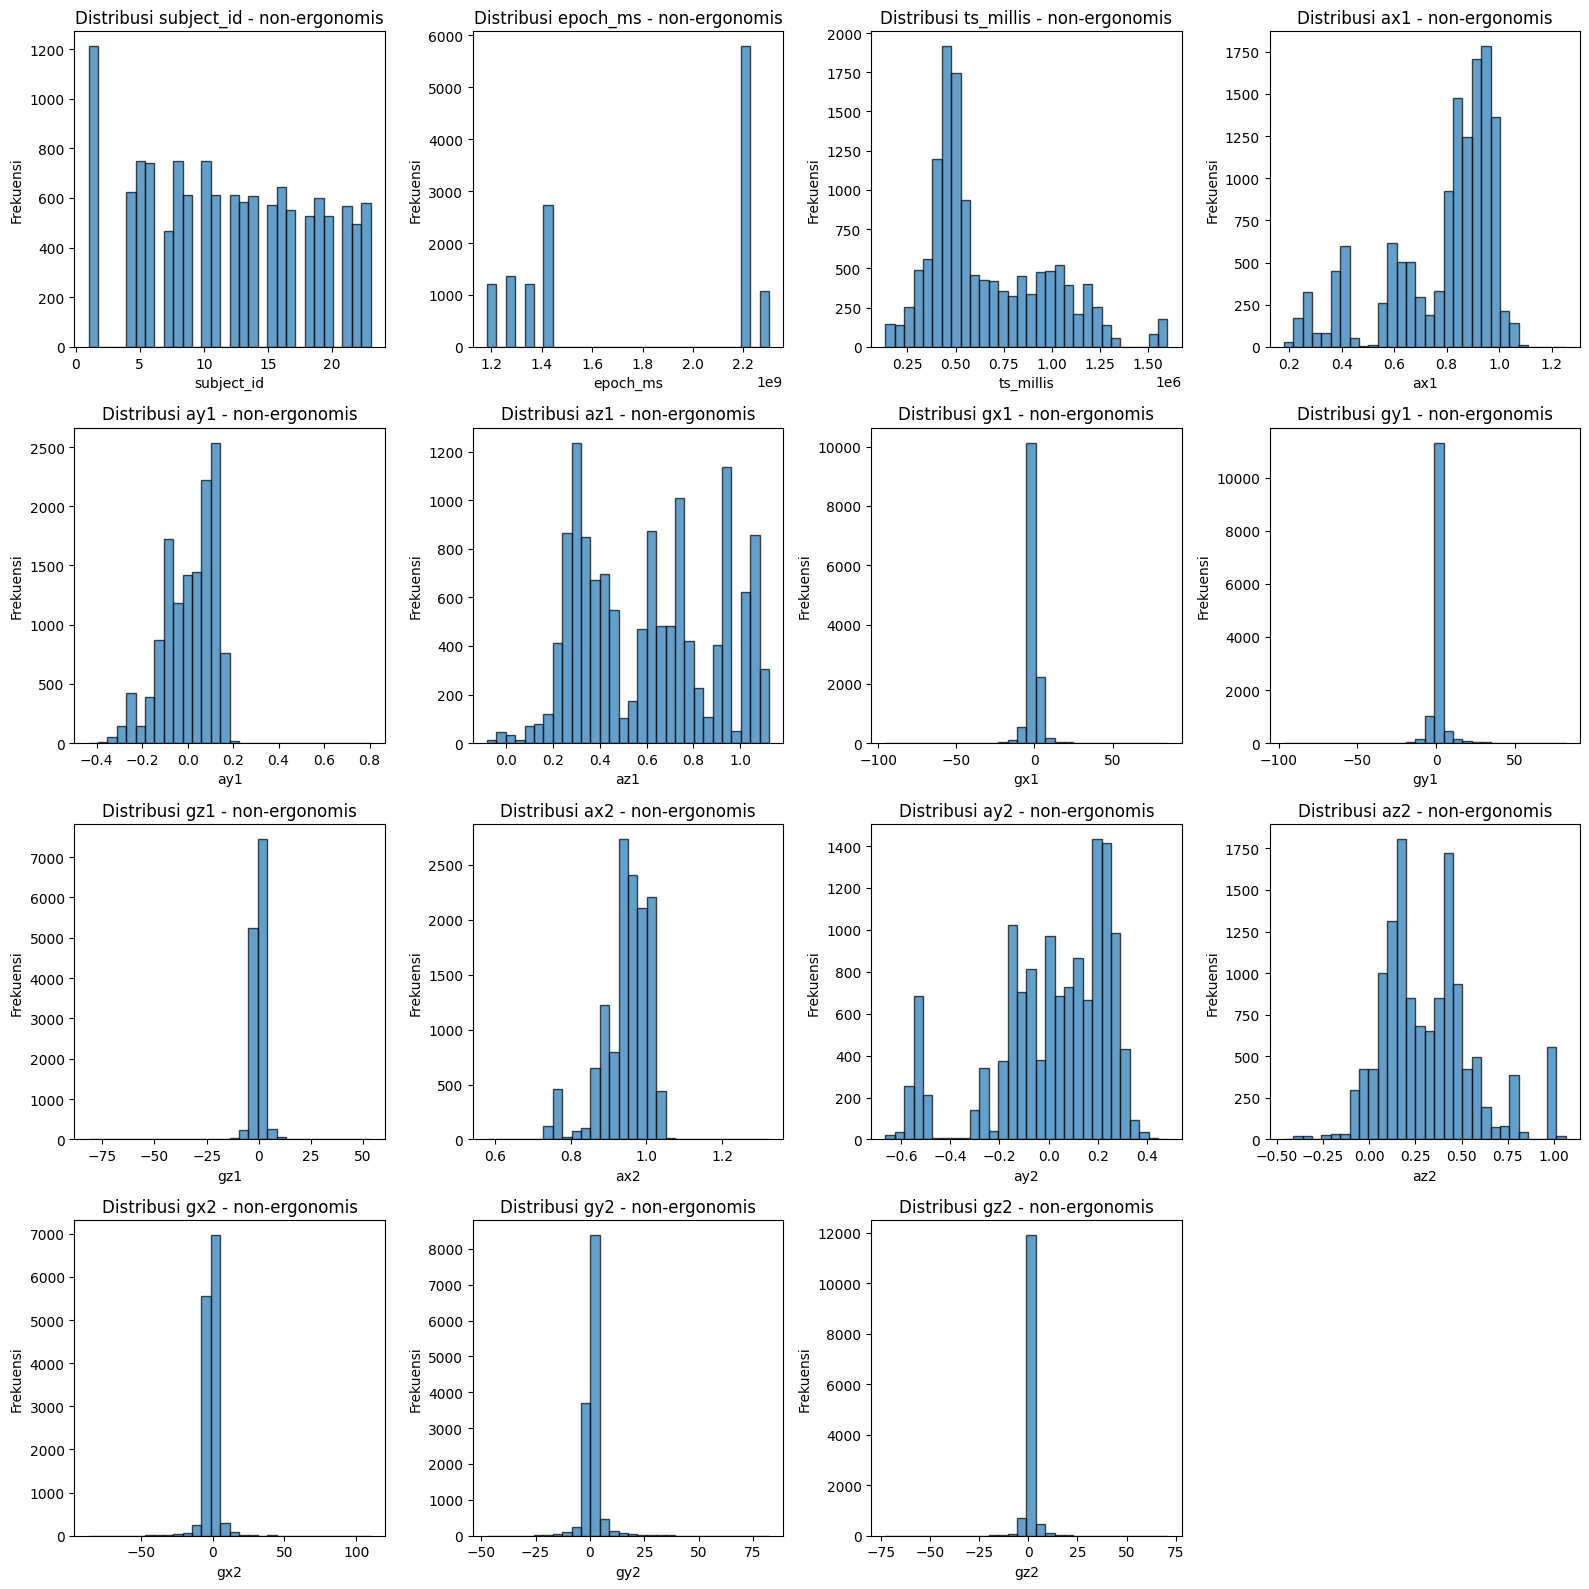

Jumlah outlier pada kolom 'ts_millis' untuk label 'non-ergonomis': 56
Jumlah outlier pada kolom 'ax1' untuk label 'non-ergonomis': 97
Jumlah outlier pada kolom 'ay1' untuk label 'non-ergonomis': 36
Jumlah outlier pada kolom 'gx1' untuk label 'non-ergonomis': 1122
Jumlah outlier pada kolom 'gy1' untuk label 'non-ergonomis': 1478
Jumlah outlier pada kolom 'gz1' untuk label 'non-ergonomis': 1972
Jumlah outlier pada kolom 'ax2' untuk label 'non-ergonomis': 634
Jumlah outlier pada kolom 'ay2' untuk label 'non-ergonomis': 29
Jumlah outlier pada kolom 'az2' untuk label 'non-ergonomis': 622
Jumlah outlier pada kolom 'gx2' untuk label 'non-ergonomis': 1895
Jumlah outlier pada kolom 'gy2' untuk label 'non-ergonomis': 2132
Jumlah outlier pada kolom 'gz2' untuk label 'non-ergonomis': 1392


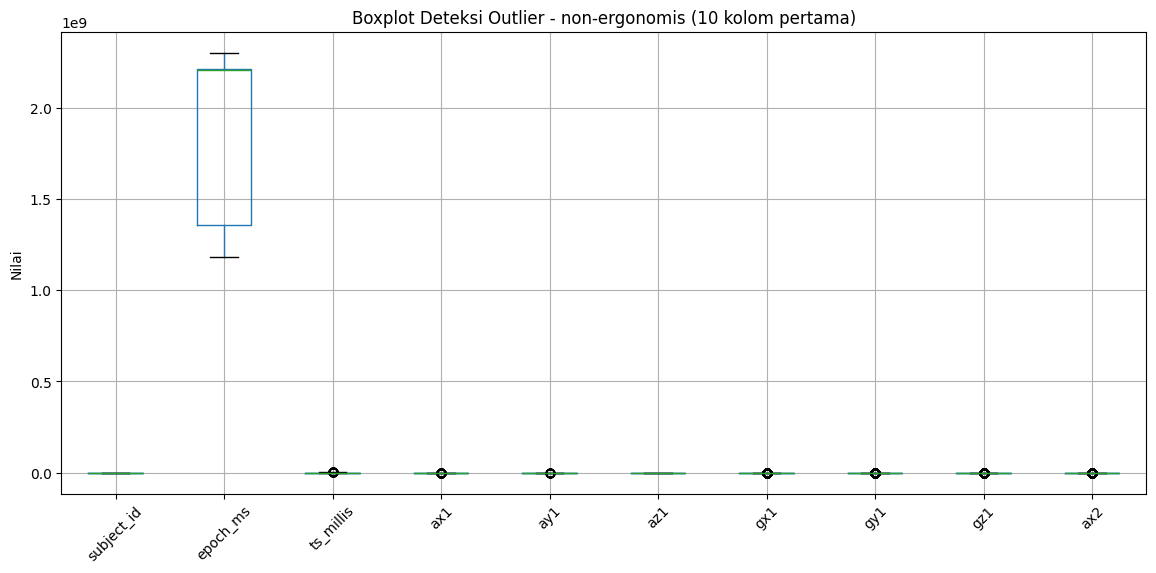

Ringkasan outlier per kolom untuk label 'non-ergonomis':
  subject_id: 0
  epoch_ms: 0
  ts_millis: 56
  ax1: 97
  ay1: 36
  az1: 0
  gx1: 1122
  gy1: 1478
  gz1: 1972
  ax2: 634
  ay2: 29
  az2: 622
  gx2: 1895
  gy2: 2132
  gz2: 1392


In [7]:
# Cell EDA 3: Distribusi dan outlier pada kolom numerik per label
import numpy as np
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Kolom numerik yang ditemukan:", num_cols)

if len(num_cols) > 0 and 'label' in df.columns:
    labels = df['label'].unique()
    print(f"Label unik: {labels}")

    for label_val in labels:
        print(f"\n--- Analisis untuk label: {label_val} ---")
        df_label = df[df['label'] == label_val]

        # Distribusi histogram per label
        n_cols_hist = len(num_cols)
        n_rows_hist = (n_cols_hist + 3) // 4
        fig, axes = plt.subplots(n_rows_hist, 4, figsize=(16, 4*n_rows_hist))
        axes = axes.flatten() if n_rows_hist > 1 else [axes] if n_cols_hist > 0 else []

        for i, col in enumerate(num_cols):
            axes[i].hist(df_label[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
            axes[i].set_title(f'Distribusi {col} - {label_val}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frekuensi')

        for j in range(i+1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

        # Deteksi outlier per label menggunakan IQR
        outliers_per_col = {}
        for col in num_cols:
            Q1 = df_label[col].quantile(0.25)
            Q3 = df_label[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df_label[(df_label[col] < lower_bound) | (df_label[col] > upper_bound)]
            outliers_per_col[col] = len(outliers)
            if len(outliers) > 0:
                print(f"Jumlah outlier pada kolom '{col}' untuk label '{label_val}': {len(outliers)}")

        # Boxplot outlier per label
        cols_to_plot = num_cols[:10]
        plt.figure(figsize=(14, 6))
        df_label[cols_to_plot].boxplot(rot=45)
        plt.title(f'Boxplot Deteksi Outlier - {label_val} (10 kolom pertama)')
        plt.ylabel('Nilai')
        plt.show()

        print(f"Ringkasan outlier per kolom untuk label '{label_val}':")
        for col, count in outliers_per_col.items():
            print(f"  {col}: {count}")
else:
    print("Tidak ada kolom numerik atau kolom 'label' tidak ditemukan.")

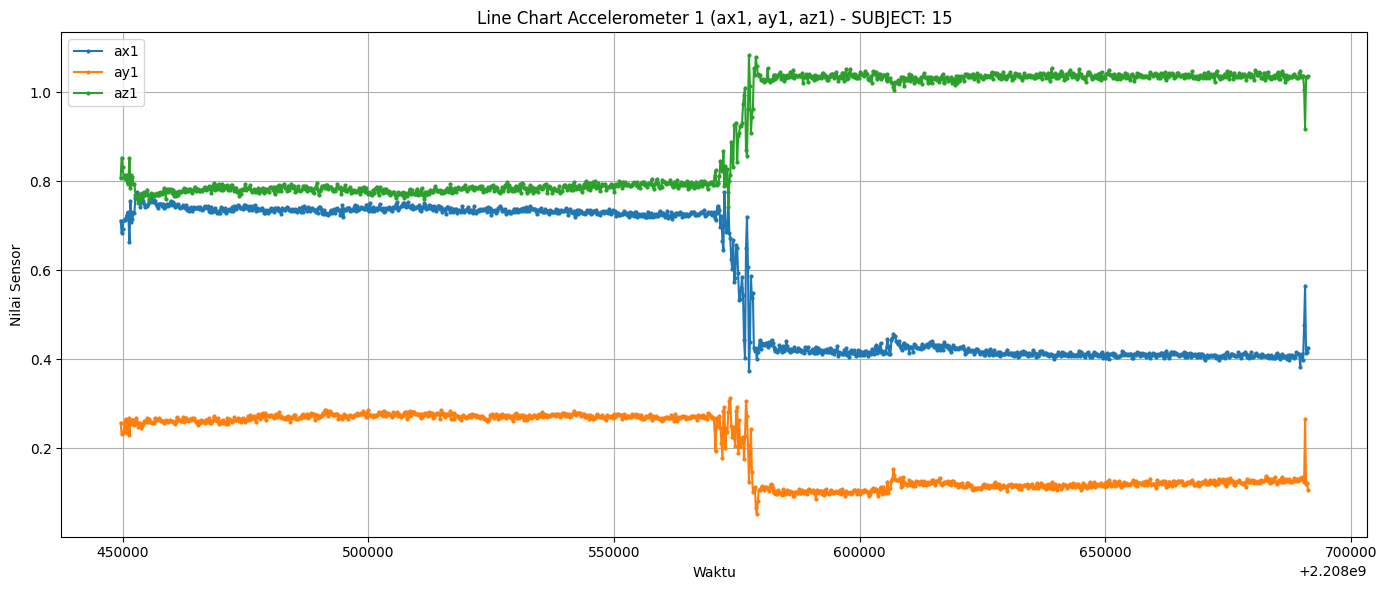

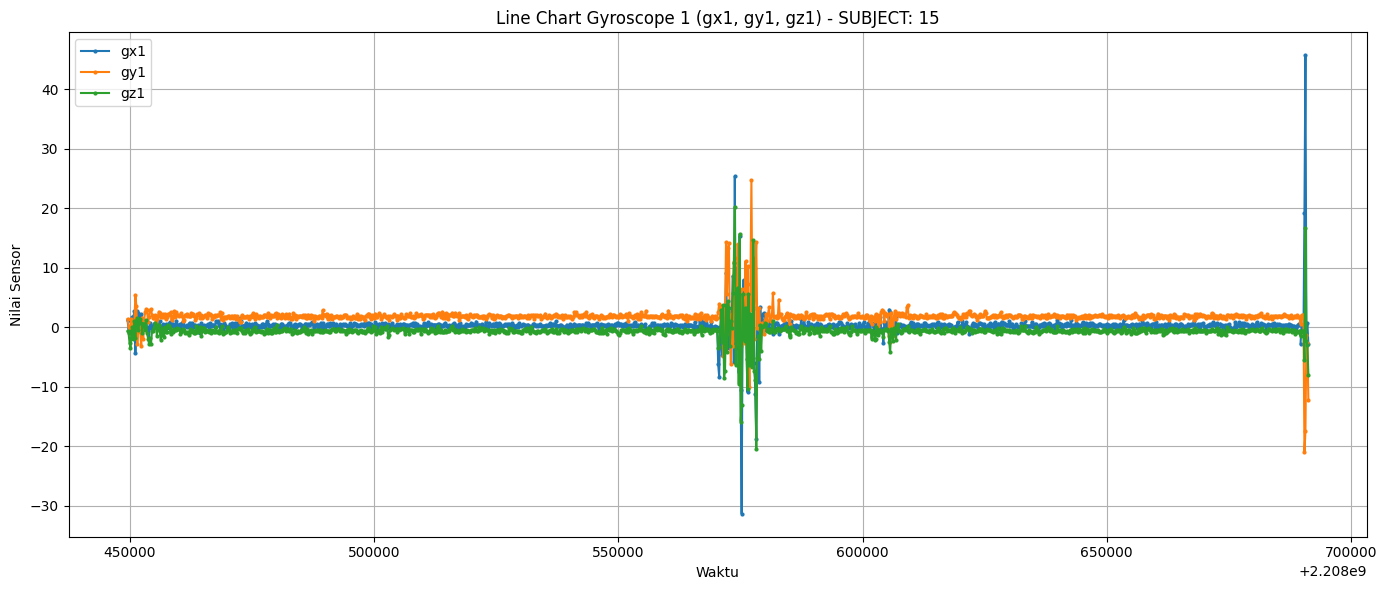

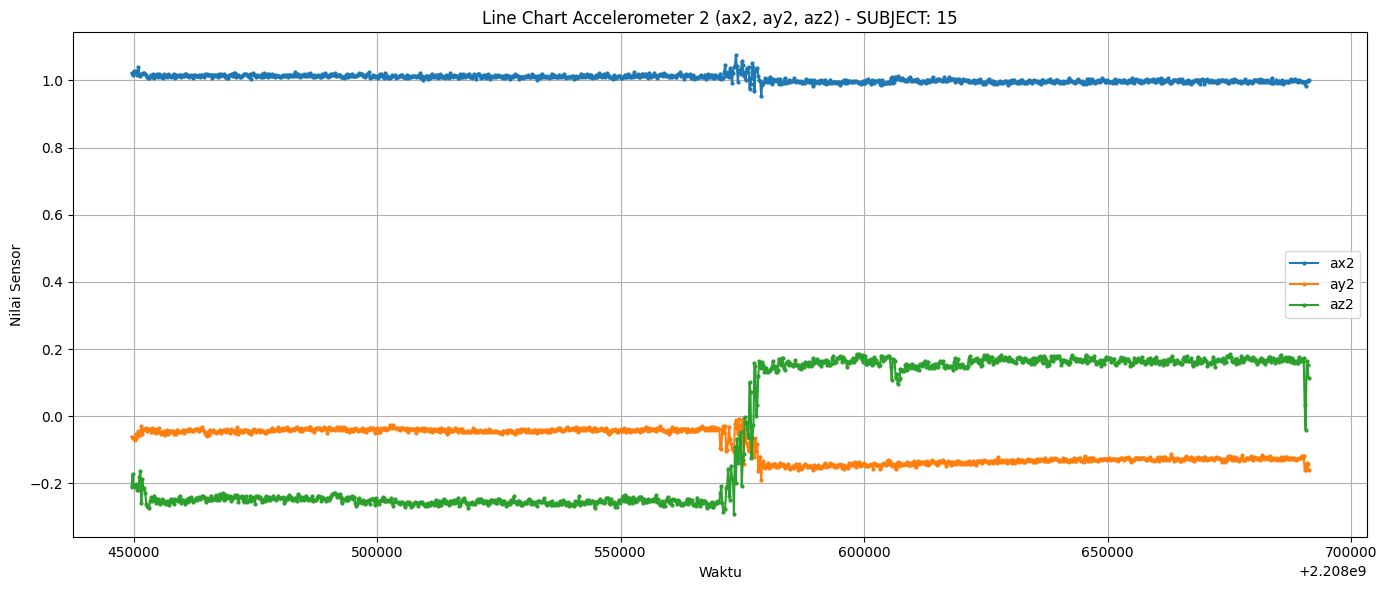

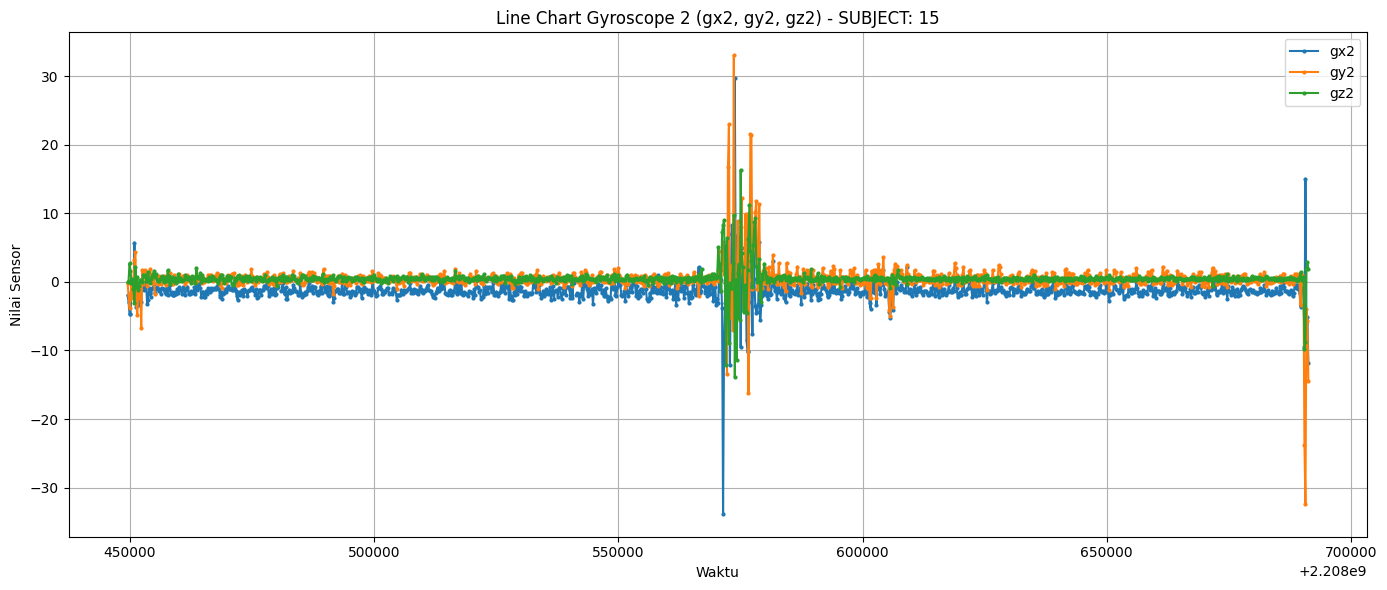

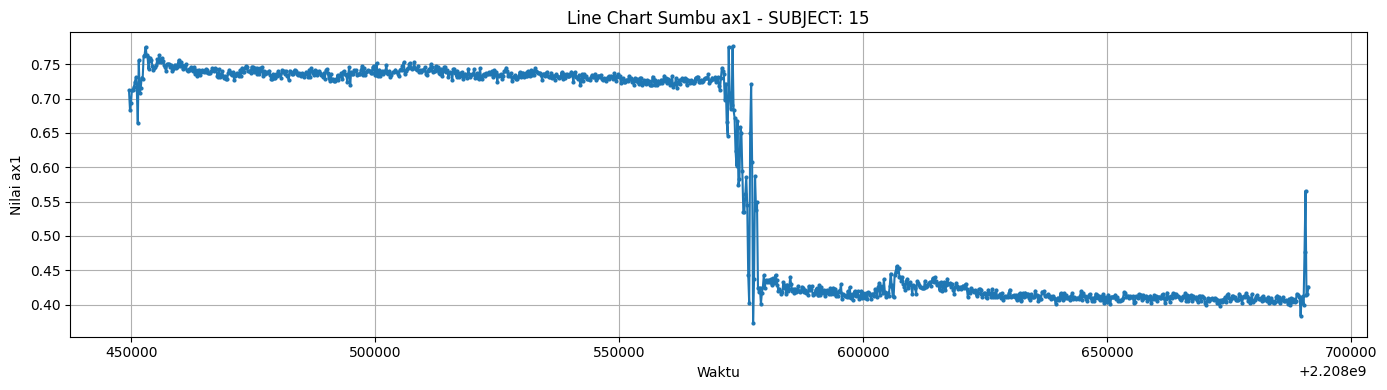

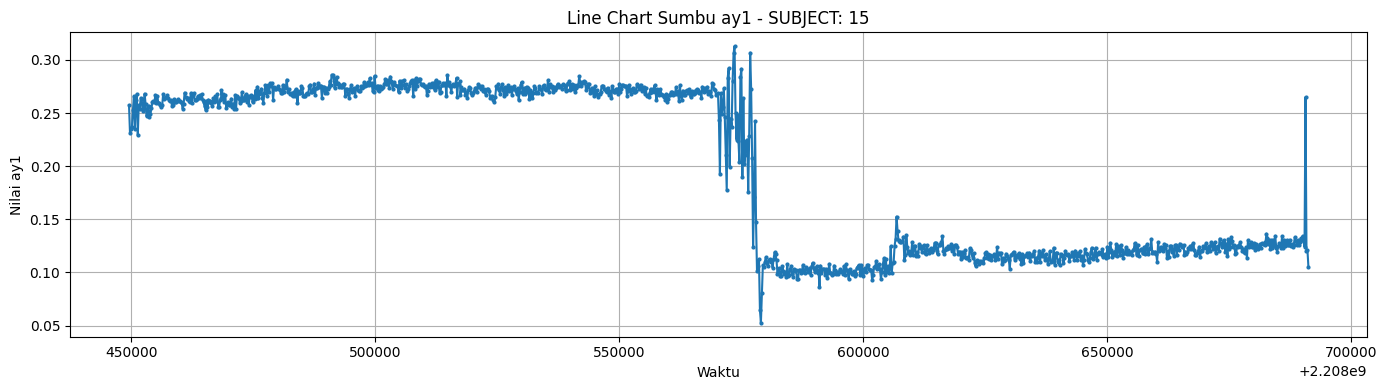

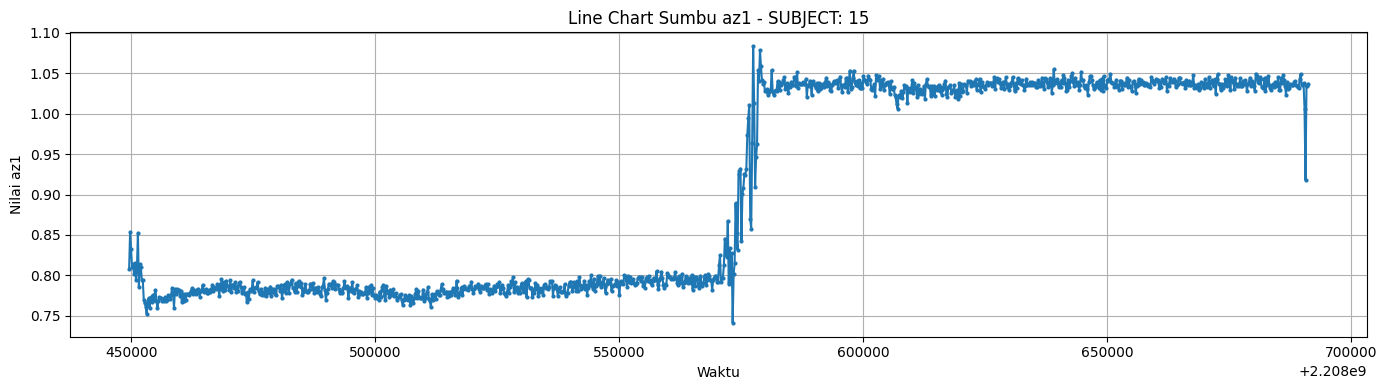

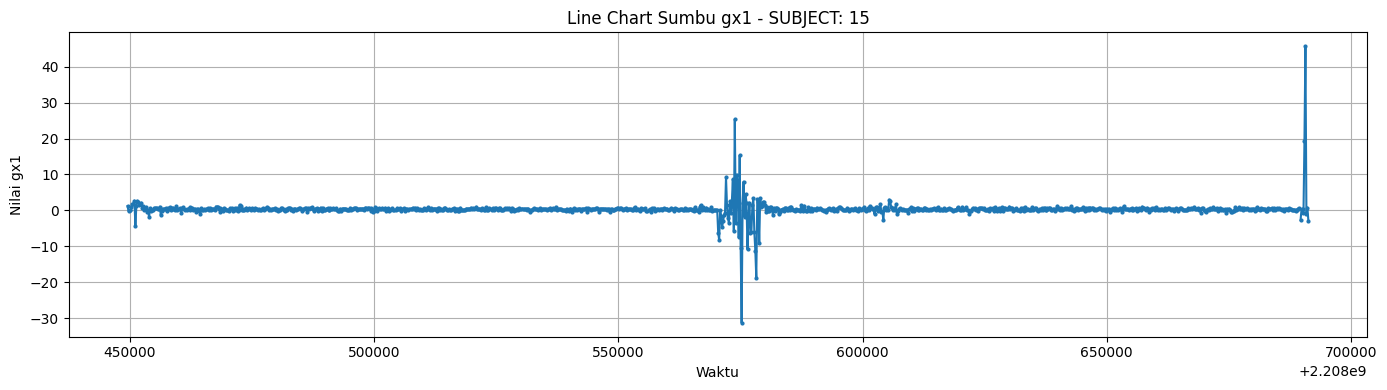

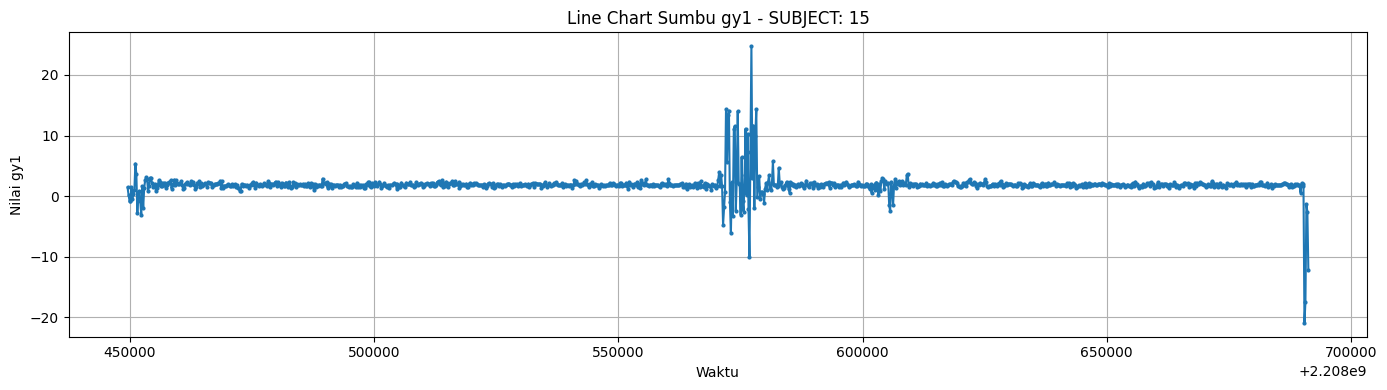

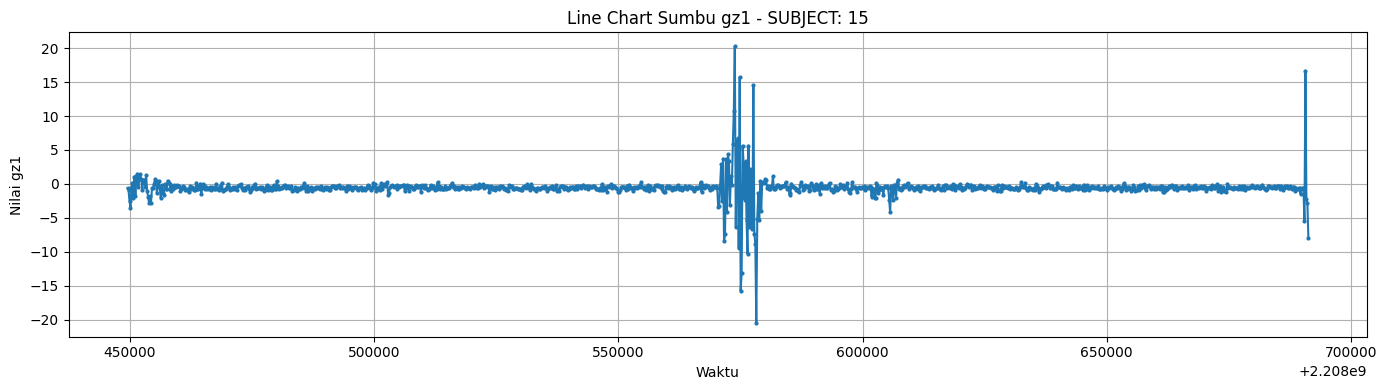

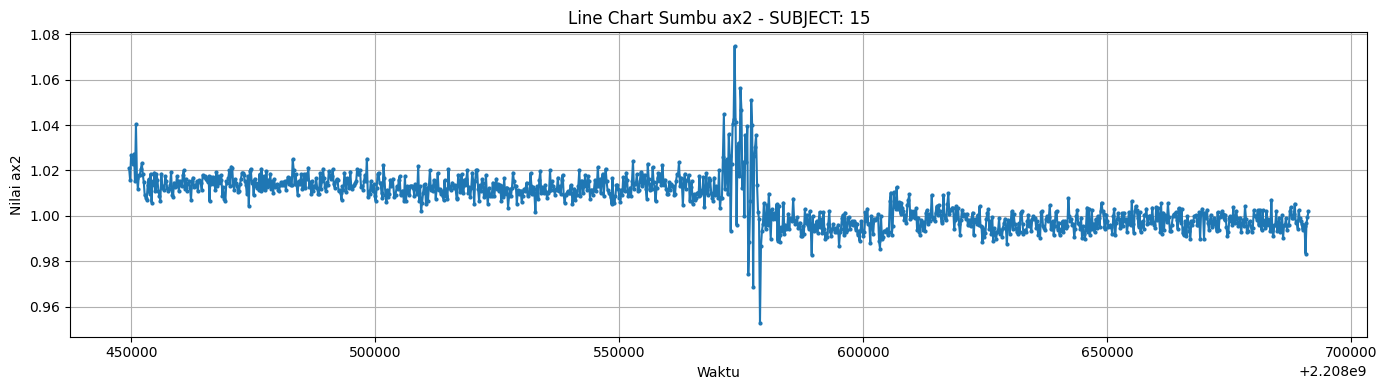

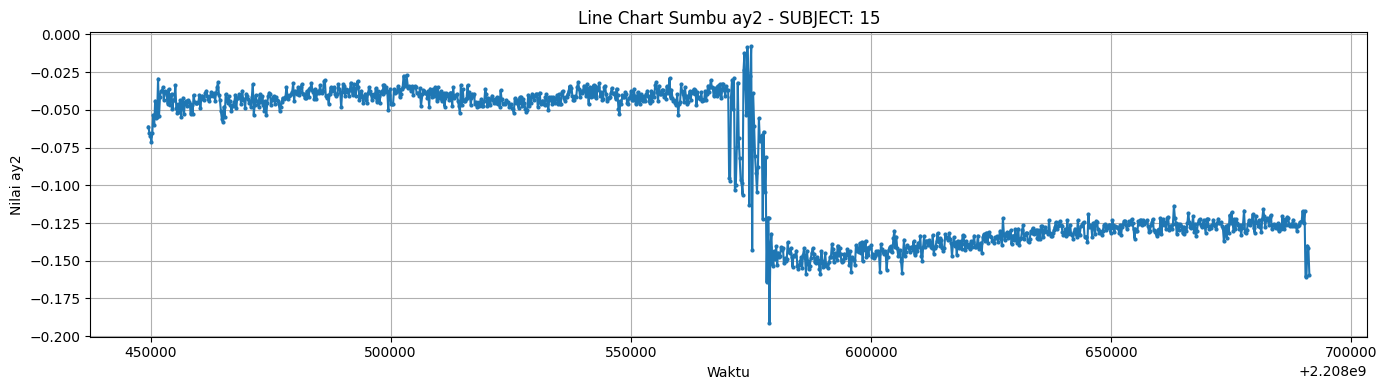

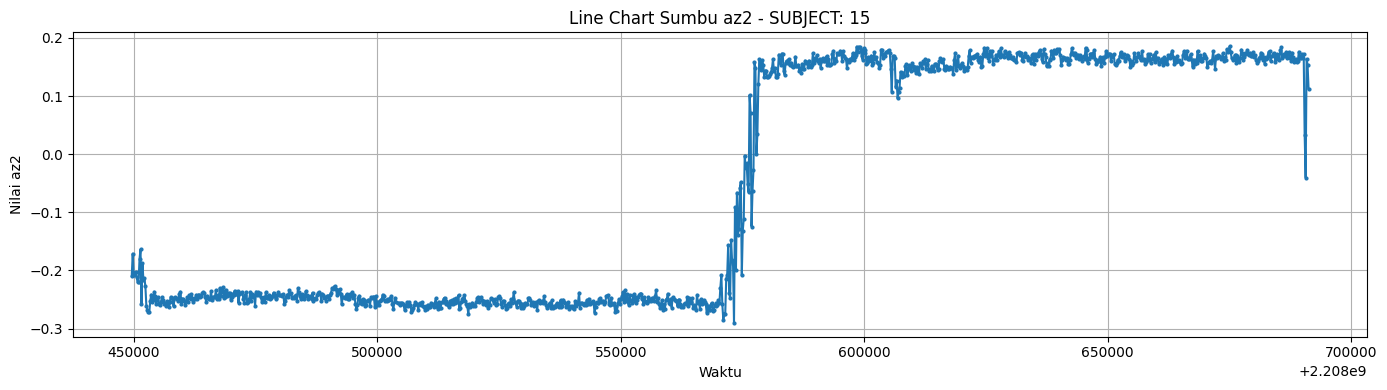

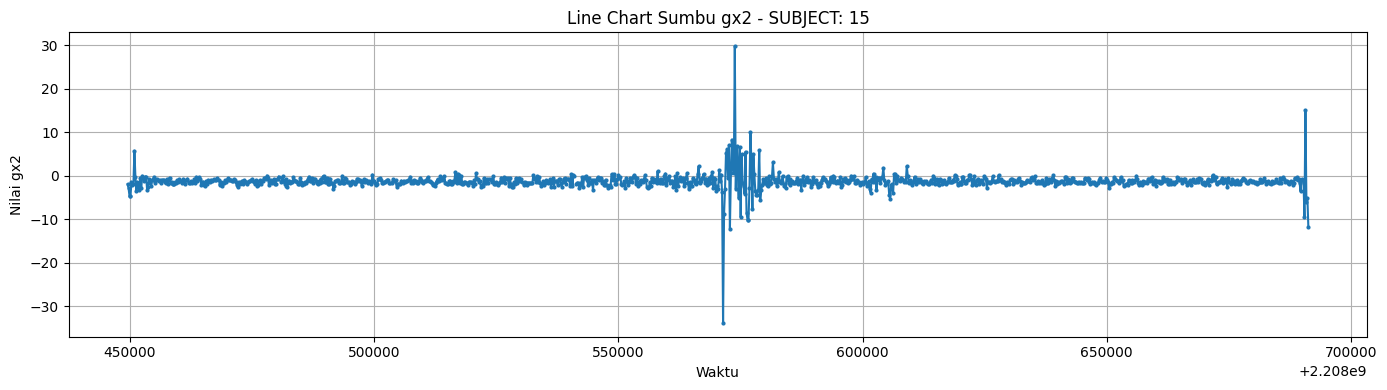

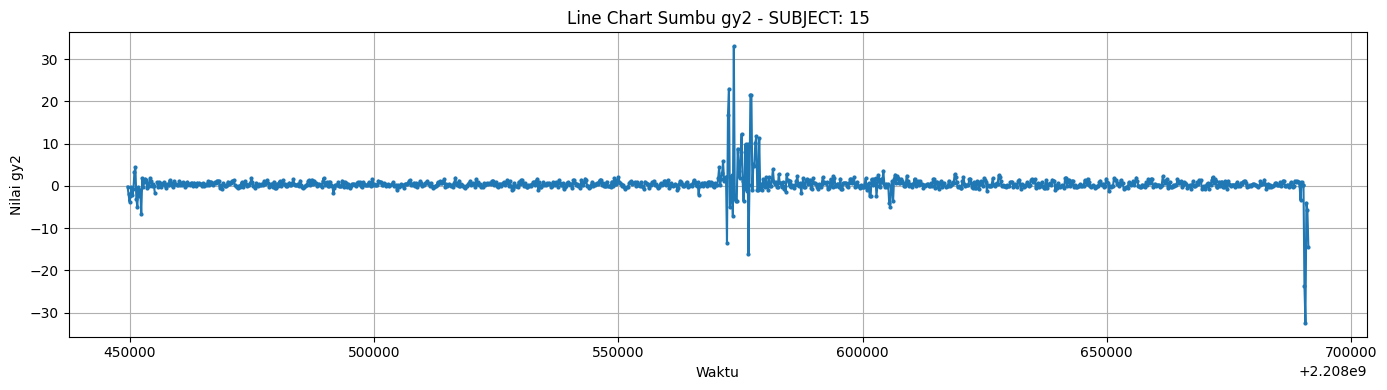

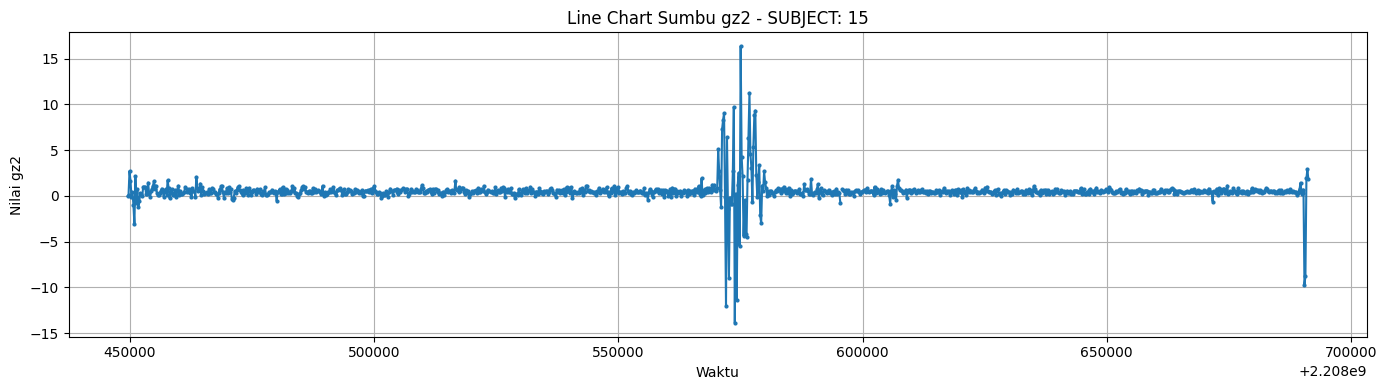

In [8]:
import matplotlib.pyplot as plt

# Input SUBJECT
SUBJECT = '15' # Changed from '004' to '1' to match 'subject_id' format

# Filter data berdasarkan SUBJECT
df_subject = df[df['subject_id'] == int(SUBJECT)].copy() # Corrected 'Subject' to 'subject_id' and converted SUBJECT to int

if df_subject.empty:
    print(f"Tidak ada data untuk SUBJECT: {SUBJECT}")
else:
    # Reset index untuk memastikan urutan waktu
    df_subject = df_subject.reset_index(drop=True)

    # Ambil kolom waktu (misalnya kolom 'Time' atau indeks jika tidak ada)
    # Sesuaikan nama kolom waktu jika berbeda
    time_col = 'epoch_ms'  # Changed to 'epoch_ms' as it exists and is numeric
    if time_col not in df_subject.columns:
        time_col = df_subject.index  # Gunakan indeks sebagai waktu jika tidak ada kolom waktu
        print(f"Kolom '{time_col}' tidak ditemukan, menggunakan indeks sebagai sumbu X.")
    else:
        time_col = df_subject[time_col]

    # Pastikan kolom sensor ada
    accel_cols_1 = ['ax1', 'ay1', 'az1'] # Updated to match df columns
    gyro_cols_1 = ['gx1', 'gy1', 'gz1']  # Updated to match df columns
    accel_cols_2 = ['ax2', 'ay2', 'az2'] # Added for second sensor
    gyro_cols_2 = ['gx2', 'gy2', 'gz2']  # Added for second sensor

    # Filter kolom yang benar-benar ada di dataframe
    existing_accel_1 = [col for col in accel_cols_1 if col in df_subject.columns]
    existing_gyro_1 = [col for col in gyro_cols_1 if col in df_subject.columns]
    existing_accel_2 = [col for col in accel_cols_2 if col in df_subject.columns]
    existing_gyro_2 = [col for col in gyro_cols_2 if col in df_subject.columns]

    if not (existing_accel_1 or existing_gyro_1 or existing_accel_2 or existing_gyro_2):
        print("Kolom sensor tidak ditemukan.")
    else:
        # Plot 1: Accelerometer 1 (ax1, ay1, az1)
        if existing_accel_1:
            plt.figure(figsize=(14, 6))
            for col in existing_accel_1:
                plt.plot(time_col, df_subject[col], label=col, marker='o', markersize=2)
            plt.title(f'Line Chart Accelerometer 1 (ax1, ay1, az1) - SUBJECT: {SUBJECT}')
            plt.xlabel('Waktu')
            plt.ylabel('Nilai Sensor')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        # Plot 2: Gyroscope 1 (gx1, gy1, gz1)
        if existing_gyro_1:
            plt.figure(figsize=(14, 6))
            for col in existing_gyro_1:
                plt.plot(time_col, df_subject[col], label=col, marker='o', markersize=2)
            plt.title(f'Line Chart Gyroscope 1 (gx1, gy1, gz1) - SUBJECT: {SUBJECT}')
            plt.xlabel('Waktu')
            plt.ylabel('Nilai Sensor')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        # Plot 3: Accelerometer 2 (ax2, ay2, az2)
        if existing_accel_2:
            plt.figure(figsize=(14, 6))
            for col in existing_accel_2:
                plt.plot(time_col, df_subject[col], label=col, marker='o', markersize=2)
            plt.title(f'Line Chart Accelerometer 2 (ax2, ay2, az2) - SUBJECT: {SUBJECT}')
            plt.xlabel('Waktu')
            plt.ylabel('Nilai Sensor')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        # Plot 4: Gyroscope 2 (gx2, gy2, gz2)
        if existing_gyro_2:
            plt.figure(figsize=(14, 6))
            for col in existing_gyro_2:
                plt.plot(time_col, df_subject[col], label=col, marker='o', markersize=2)
            plt.title(f'Line Chart Gyroscope 2 (gx2, gy2, gz2) - SUBJECT: {SUBJECT}')
            plt.xlabel('Waktu')
            plt.ylabel('Nilai Sensor')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        # Plot per sumbu (1 chart per sumbu) - Combined for all sensors
        all_sensors = existing_accel_1 + existing_gyro_1 + existing_accel_2 + existing_gyro_2
        for col in all_sensors:
            plt.figure(figsize=(14, 4))
            plt.plot(time_col, df_subject[col], marker='o', markersize=2)
            plt.title(f'Line Chart Sumbu {col} - SUBJECT: {SUBJECT}')
            plt.xlabel('Waktu')
            plt.ylabel(f'Nilai {col}')
            plt.grid(True)
            plt.tight_layout()
            plt.show()

### Distribusi Per Label

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==============================================================================
# 1. GABUNG SEMUA DATA
# ==============================================================================

# Opsi A: Jika data berasal dari beberapa file CSV dalam satu folder
def gabung_data_dari_folder(folder_path):
    """
    Menggabungkan semua file CSV dalam satu folder menjadi satu DataFrame.
    """
    path = Path(folder_path)
    csv_files = list(path.glob('*.csv'))

    if not csv_files:
        raise FileNotFoundError(f"Tidak ada file CSV ditemukan di {folder_path}")

    print(f"Ditemukan {len(csv_files)} file CSV. Menggabungkan...")

    df_list = []
    for file in csv_files:
        df = pd.read_csv(file)
        df['source_file'] = file.name  # Tambahkan kolom untuk tracking sumber data
        df_list.append(df)
        print(f"  ✓ {file.name}: {len(df)} baris")

    df_gabung = pd.concat(df_list, ignore_index=True)
    print(f"\n✓ Total data setelah digabung: {len(df_gabung)} baris")
    return df_gabung

# Opsi B: Jika data sudah ada dalam beberapa DataFrame
def gabung_dataframe(list_df):
    """
    Menggabungkan beberapa DataFrame menjadi satu.
    """
    print(f"Menggabungkan {len(list_df)} DataFrame...")
    df_gabung = pd.concat(list_df, ignore_index=True)
    print(f"✓ Total data setelah digabung: {len(df_gabung)} baris")
    return df_gabung

# ==============================================================================
# 2. GROUP BY LABEL & STATISTIK DASAR
# ==============================================================================

def analisis_per_label(df, label_col='label'):
    """
    Menampilkan statistik dasar per label.
    """
    print("\n" + "="*60)
    print("STATISTIK PER LABEL")
    print("="*60)

    # Group by label
    grouped = df.groupby(label_col)

    # Tampilkan jumlah sampel per label
    print("\nJumlah Sampel per Label:")
    print(grouped.size())

    # Tampilkan statistik deskriptif untuk setiap label
    print("\nStatistik Akselerometer per Label:")
    accel_cols = ['ax1', 'ay1', 'az1', 'ax2', 'ay2', 'az2']
    accel_cols = [c for c in accel_cols if c in df.columns]
    if accel_cols:
        print(grouped[accel_cols].describe())

    print("\nStatistik Gyroscope per Label:")
    gyro_cols = ['gx1', 'gy1', 'gz1', 'gx2', 'gy2', 'gz2']
    gyro_cols = [c for c in gyro_cols if c in df.columns]
    if gyro_cols:
        print(grouped[gyro_cols].describe())

    return grouped

# ==============================================================================
# 3. VISUALISASI LINE CHART AKSELEROMETER PER LABEL
# ==============================================================================

def plot_accel_per_label(df, label_col='label', sensor_id=1, max_samples=500):
    """
    Membuat line chart sumbu akselerometer per label.

    Parameters:
    - df: DataFrame yang sudah digabung
    - label_col: nama kolom label
    - sensor_id: 1 atau 2 (untuk ax1/ay1/az1 atau ax2/ay2/az2)
    - max_samples: jumlah maksimum sampel yang ditampilkan per label (untuk performa)
    """
    print(f"\nMembuat visualisasi Akselerometer Sensor {sensor_id}...")

    # Tentukan kolom berdasarkan sensor_id
    if sensor_id == 1:
        cols = ['ax1', 'ay1', 'az1']
        title_prefix = 'Akselerometer Sensor 1'
    else:
        cols = ['ax2', 'ay2', 'az2']
        title_prefix = 'Akselerometer Sensor 2'

    # Cek apakah kolom ada
    cols = [c for c in cols if c in df.columns]
    if not cols:
        print(f"⚠ Kolom {cols} tidak ditemukan dalam data")
        return

    # Dapatkan semua label unik
    labels = df[label_col].unique()
    n_labels = len(labels)

    # Buat figure dengan subplots
    fig, axes = plt.subplots(n_labels, 1, figsize=(14, 4 * n_labels))
    if n_labels == 1:
        axes = [axes]

    # Plot untuk setiap label
    for idx, label in enumerate(labels):
        ax = axes[idx]

        # Ambil data untuk label ini
        df_label = df[df[label_col] == label].copy()

        # Batasi jumlah sampel untuk performa visualisasi
        if len(df_label) > max_samples:
            df_label = df_label.sample(n=max_samples, random_state=42).sort_index()
            title_suffix = f'(sampel acak: {max_samples})'
        else:
            title_suffix = f'(total: {len(df_label)} sampel)'

        # Plot setiap sumbu
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Merah, Hijau, Biru
        for i, col in enumerate(cols):
            ax.plot(df_label.index, df_label[col],
                   label=col, color=colors[i], alpha=0.7, linewidth=1.5)

        ax.set_title(f'{title_prefix} - Label: {label} {title_suffix}',
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Sample Index')
        ax.set_ylabel('Acceleration (m/s²)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 4. VISUALISASI LINE CHART GYROSCOPE PER LABEL
# ==============================================================================

def plot_gyro_per_label(df, label_col='label', sensor_id=1, max_samples=500):
    """
    Membuat line chart sumbu gyroscope per label.

    Parameters:
    - df: DataFrame yang sudah digabung
    - label_col: nama kolom label
    - sensor_id: 1 atau 2 (untuk gx1/gy1/gz1 atau gx2/gy2/gz2)
    - max_samples: jumlah maksimum sampel yang ditampilkan per label (untuk performa)
    """
    print(f"\nMembuat visualisasi Gyroscope Sensor {sensor_id}...")

    # Tentukan kolom berdasarkan sensor_id
    if sensor_id == 1:
        cols = ['gx1', 'gy1', 'gz1']
        title_prefix = 'Gyroscope Sensor 1'
    else:
        cols = ['gx2', 'gy2', 'gz2']
        title_prefix = 'Gyroscope Sensor 2'

    # Cek apakah kolom ada
    cols = [c for c in cols if c in df.columns]
    if not cols:
        print(f"⚠ Kolom {cols} tidak ditemukan dalam data")
        return

    # Dapatkan semua label unik
    labels = df[label_col].unique()
    n_labels = len(labels)

    # Buat figure dengan subplots
    fig, axes = plt.subplots(n_labels, 1, figsize=(14, 4 * n_labels))
    if n_labels == 1:
        axes = [axes]

    # Plot untuk setiap label
    for idx, label in enumerate(labels):
        ax = axes[idx]

        # Ambil data untuk label ini
        df_label = df[df[label_col] == label].copy()

        # Batasi jumlah sampel untuk performa visualisasi
        if len(df_label) > max_samples:
            df_label = df_label.sample(n=max_samples, random_state=42).sort_index()
            title_suffix = f'(sampel acak: {max_samples})'
        else:
            title_suffix = f'(total: {len(df_label)} sampel)'

        # Plot setiap sumbu
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Merah, Hijau, Biru
        for i, col in enumerate(cols):
            ax.plot(df_label.index, df_label[col],
                   label=col, color=colors[i], alpha=0.7, linewidth=1.5)

        ax.set_title(f'{title_prefix} - Label: {label} {title_suffix}',
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Sample Index')
        ax.set_ylabel('Angular Velocity (°/s)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 5. VISUALISASI TAMBAHAN: BOXPLOT PER LABEL
# ==============================================================================

def plot_boxplot_per_label(df, label_col='label'):
    """
    Membuat boxplot untuk melihat distribusi data per label.
    """
    print("\nMembuat boxplot per label...")

    # Akselerometer
    accel_cols = [c for c in ['ax1', 'ay1', 'az1', 'ax2', 'ay2', 'az2'] if c in df.columns]
    if accel_cols:
        fig, axes = plt.subplots(1, len(accel_cols), figsize=(5 * len(accel_cols), 6))
        if len(accel_cols) == 1:
            axes = [axes]

        for idx, col in enumerate(accel_cols):
            sns.boxplot(data=df, x=label_col, y=col, ax=axes[idx], palette='Set2')
            axes[idx].set_title(f'{col} per Label', fontsize=12, fontweight='bold')
            axes[idx].grid(True, alpha=0.3)

        plt.suptitle('Distribusi Akselerometer per Label', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    # Gyroscope
    gyro_cols = [c for c in ['gx1', 'gy1', 'gz1', 'gx2', 'gy2', 'gz2'] if c in df.columns]
    if gyro_cols:
        fig, axes = plt.subplots(1, len(gyro_cols), figsize=(5 * len(gyro_cols), 6))
        if len(gyro_cols) == 1:
            axes = [axes]

        for idx, col in enumerate(gyro_cols):
            sns.boxplot(data=df, x=label_col, y=col, ax=axes[idx], palette='Set3')
            axes[idx].set_title(f'{col} per Label', fontsize=12, fontweight='bold')
            axes[idx].grid(True, alpha=0.3)

        plt.suptitle('Distribusi Gyroscope per Label', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

# ==============================================================================
# CONTOH PENGGUNAAN
# ==============================================================================

if __name__ == "__main__":
    # --- CONTOH 1: Gabung dari folder ---
    # df_all = gabung_data_dari_folder('./data_sensor/')

    # --- CONTOH 2: Gabung dari DataFrame yang sudah ada ---
    # df_all = gabung_dataframe([df1, df2, df3])

    # --- CONTOH 3: Jika sudah punya DataFrame df_all ---
    # Analisis per label
    # grouped = analisis_per_label(df_all, label_col='label')

    # Visualisasi line chart
    # plot_accel_per_label(df_all, label_col='label', sensor_id=1, max_samples=500)
    # plot_accel_per_label(df_all, label_col='label', sensor_id=2, max_samples=500)
    # plot_gyro_per_label(df_all, label_col='label', sensor_id=1, max_samples=500)
    # plot_gyro_per_label(df_all, label_col='label', sensor_id=2, max_samples=500)

    # Visualisasi boxplot
    # plot_boxplot_per_label(df_all, label_col='label')

    print("\n✓ Kode siap digunakan!")
    print("\nCara menggunakan:")
    print("1. Gunakan gabung_data_dari_folder() atau gabung_dataframe() untuk menggabungkan data")
    print("2. Gunakan analisis_per_label() untuk melihat statistik")
    print("3. Gunakan plot_accel_per_label() dan plot_gyro_per_label() untuk visualisasi")
    print("4. Gunakan plot_boxplot_per_label() untuk melihat distribusi data")


✓ Kode siap digunakan!

Cara menggunakan:
1. Gunakan gabung_data_dari_folder() atau gabung_dataframe() untuk menggabungkan data
2. Gunakan analisis_per_label() untuk melihat statistik
3. Gunakan plot_accel_per_label() dan plot_gyro_per_label() untuk visualisasi
4. Gunakan plot_boxplot_per_label() untuk melihat distribusi data


Ditemukan 21 file CSV. Menggabungkan...
  ✓ gabungan_mpu_fathur.csv: 1203 baris
  ✓ gabungan_mpu_ilmi.csv: 1149 baris
  ✓ gabungan_mpu_fateh.csv: 1102 baris
  ✓ gabungan_mpu_dina.csv: 978 baris
  ✓ gabungan_mpu_fatim.csv: 1207 baris
  ✓ gabungan_mpu_kelvin.csv: 1498 baris
  ✓ gabungan_mpu_nahwa.csv: 1217 baris
  ✓ gabungan_mpu_nisa.csv: 1500 baris
  ✓ gabungan_mpu_padli.csv: 1081 baris
  ✓ gabungan_mpu_rina.csv: 1134 baris
  ✓ gabungan_mpu_sultan.csv: 1078 baris
  ✓ gabungan_mpu_sofi.csv: 1258 baris
  ✓ gabungan_mpu_yunda.csv: 1210 baris
  ✓ gabungan_mpu_sutri.csv: 1495 baris
  ✓ gabungan_mpu_adnin.csv: 1311 baris
  ✓ gabungan_mpu_alam.csv: 1480 baris
  ✓ gabungan_mpu_arlin.csv: 1200 baris
  ✓ gabungan_mpu_ayuk.csv: 1203 baris
  ✓ gabungan_mpu_brian.csv: 1020 baris
  ✓ gabungan_mpu_dika.csv: 1170 baris
  ✓ gabungan_mpu_alifi.csv: 3560 baris

✓ Total data setelah digabung: 28054 baris

STATISTIK PER LABEL

Jumlah Sampel per Label:
label
ergonomis        14678
non-ergonomis    13376
dtyp

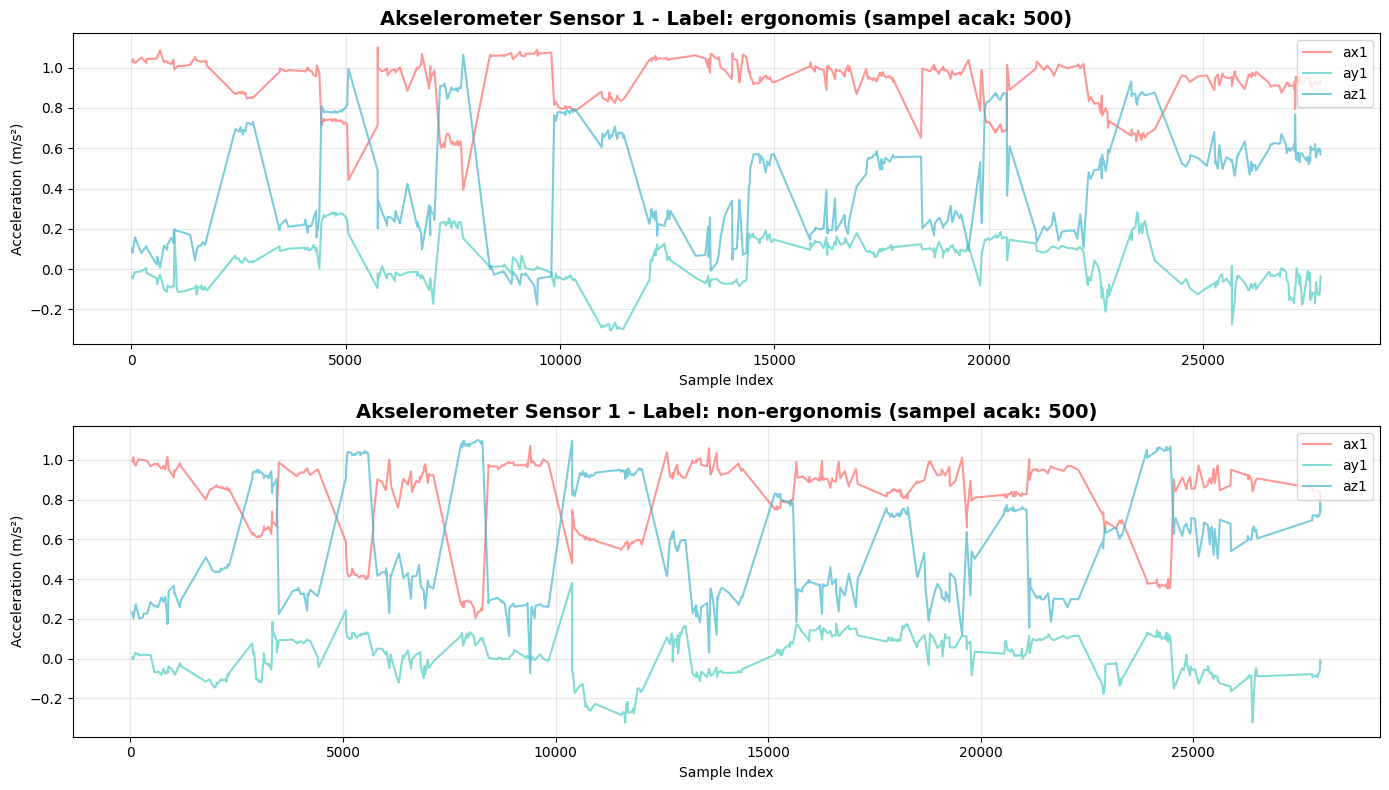


Membuat visualisasi Akselerometer Sensor 2...


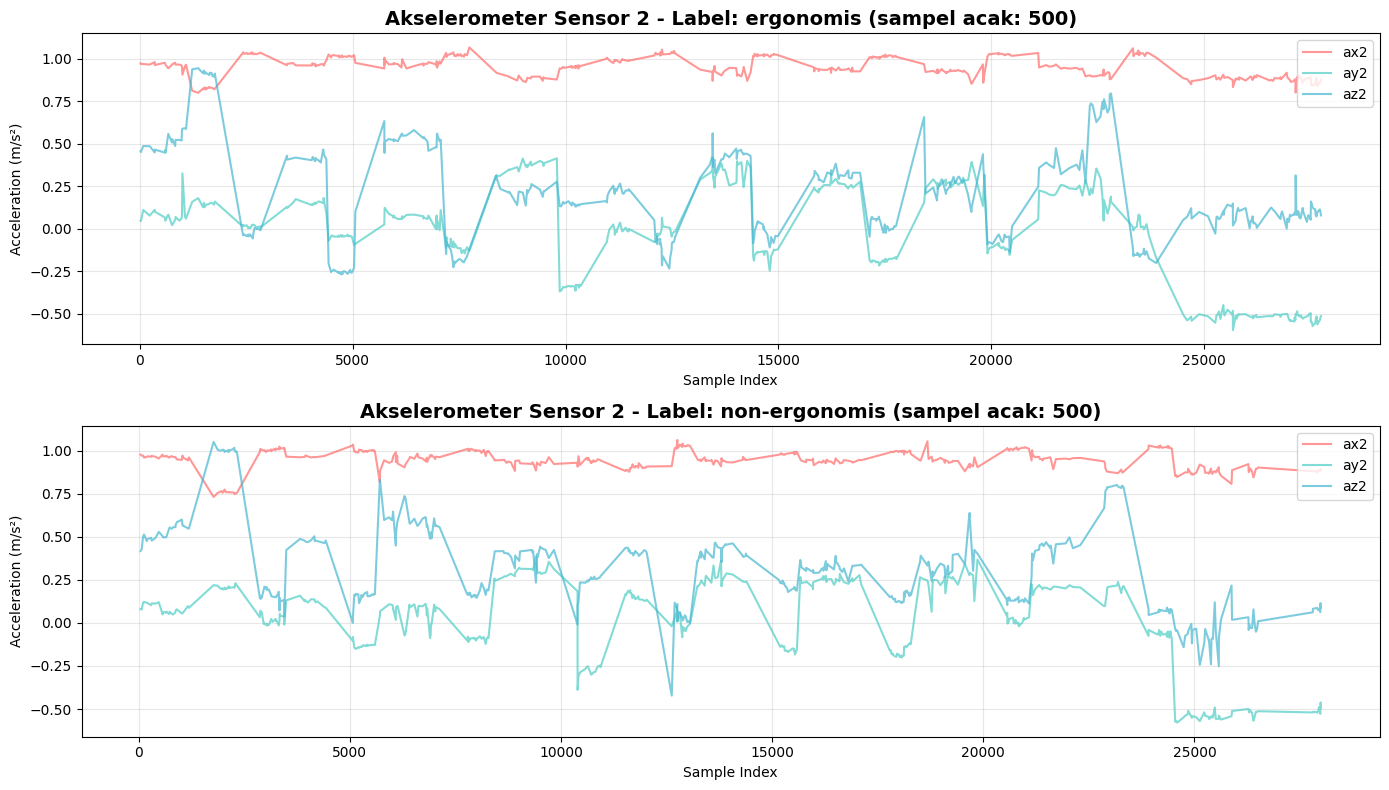


Membuat visualisasi Gyroscope Sensor 1...


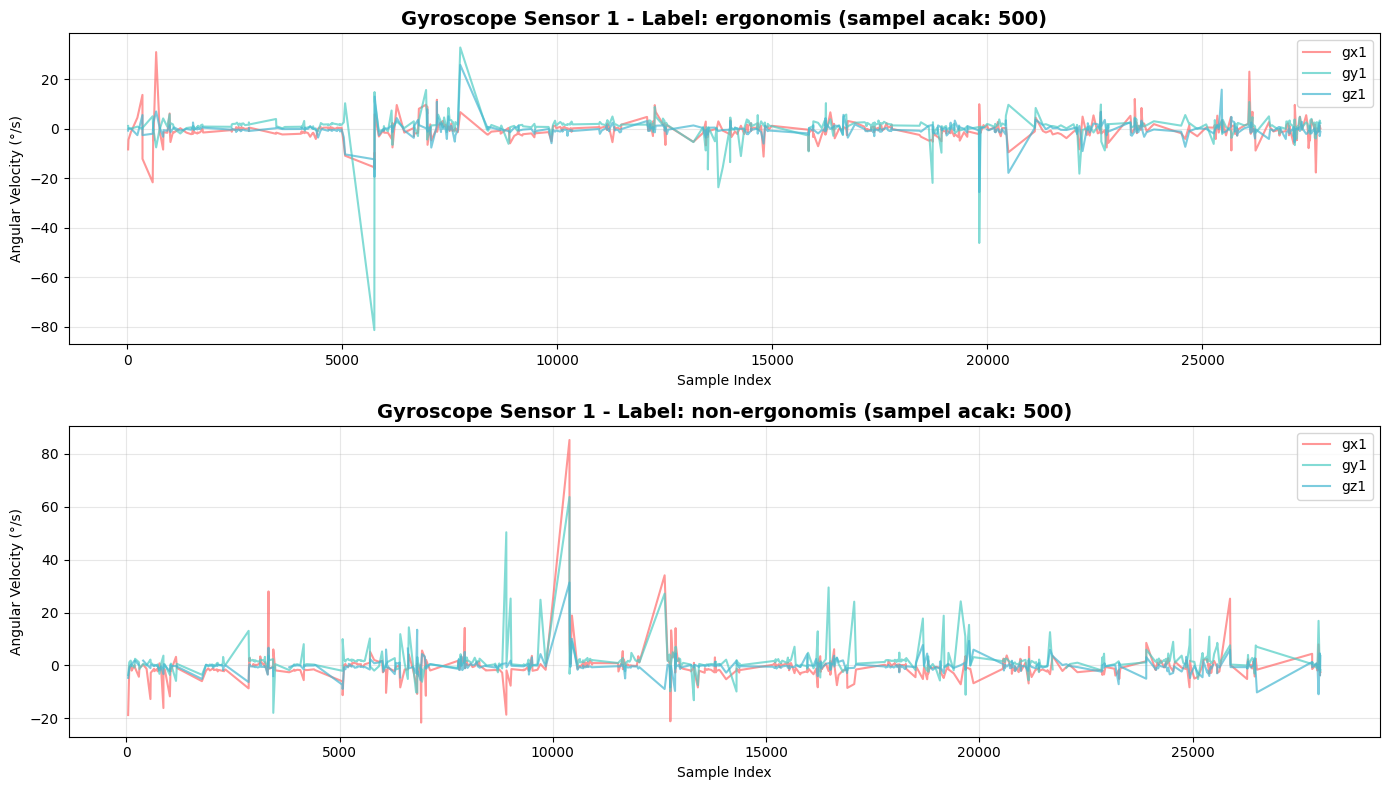


Membuat visualisasi Gyroscope Sensor 2...


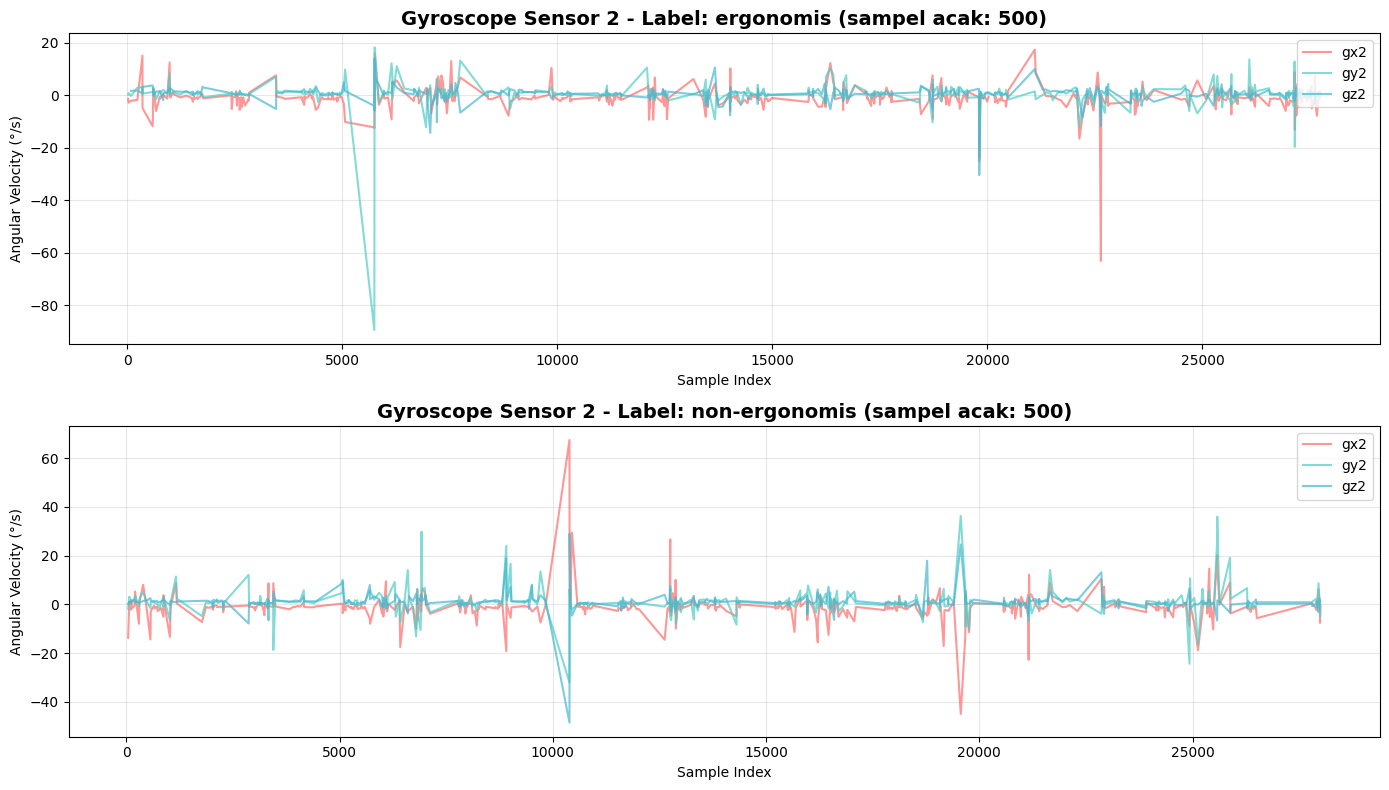


Membuat visualisasi Akselerometer Sensor 1...


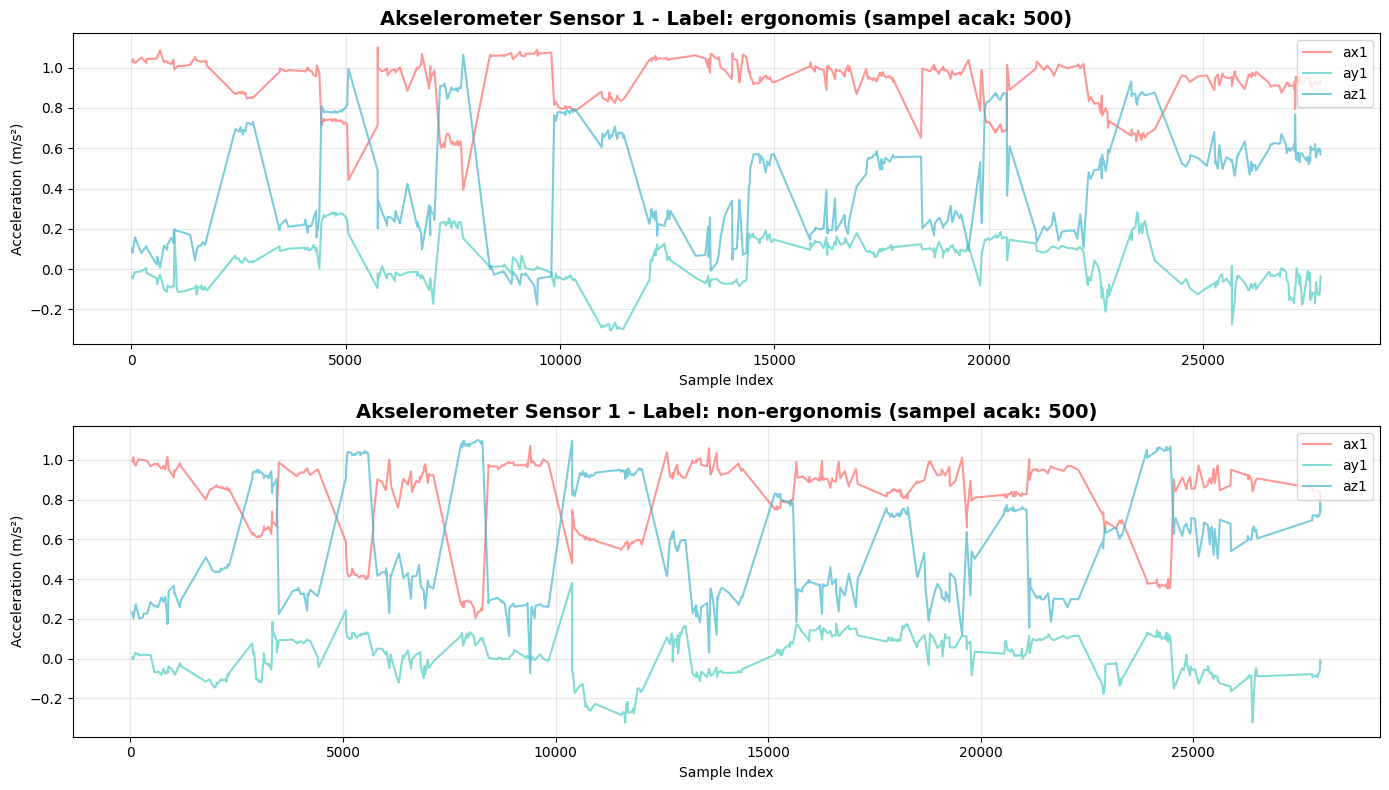


Membuat visualisasi Akselerometer Sensor 2...


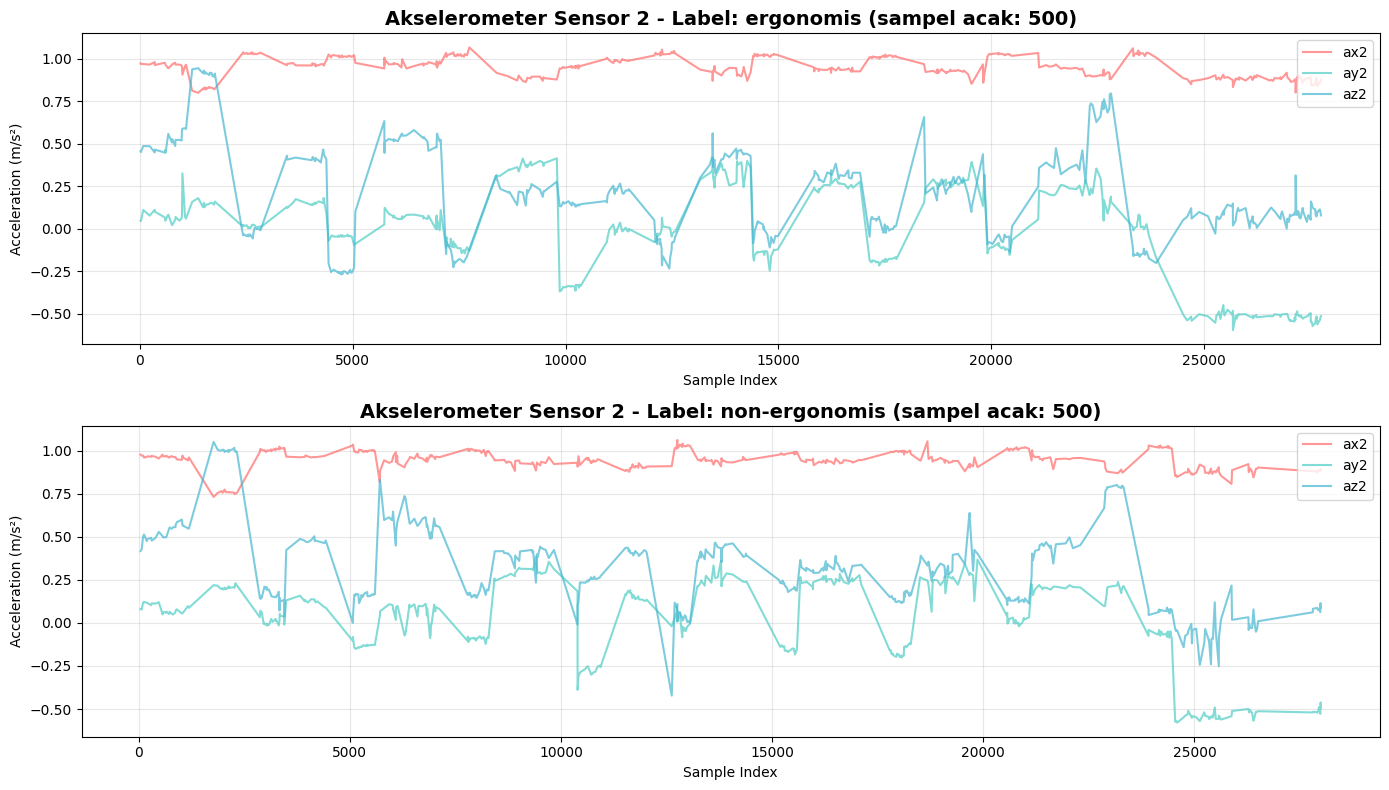


Membuat visualisasi Gyroscope Sensor 1...


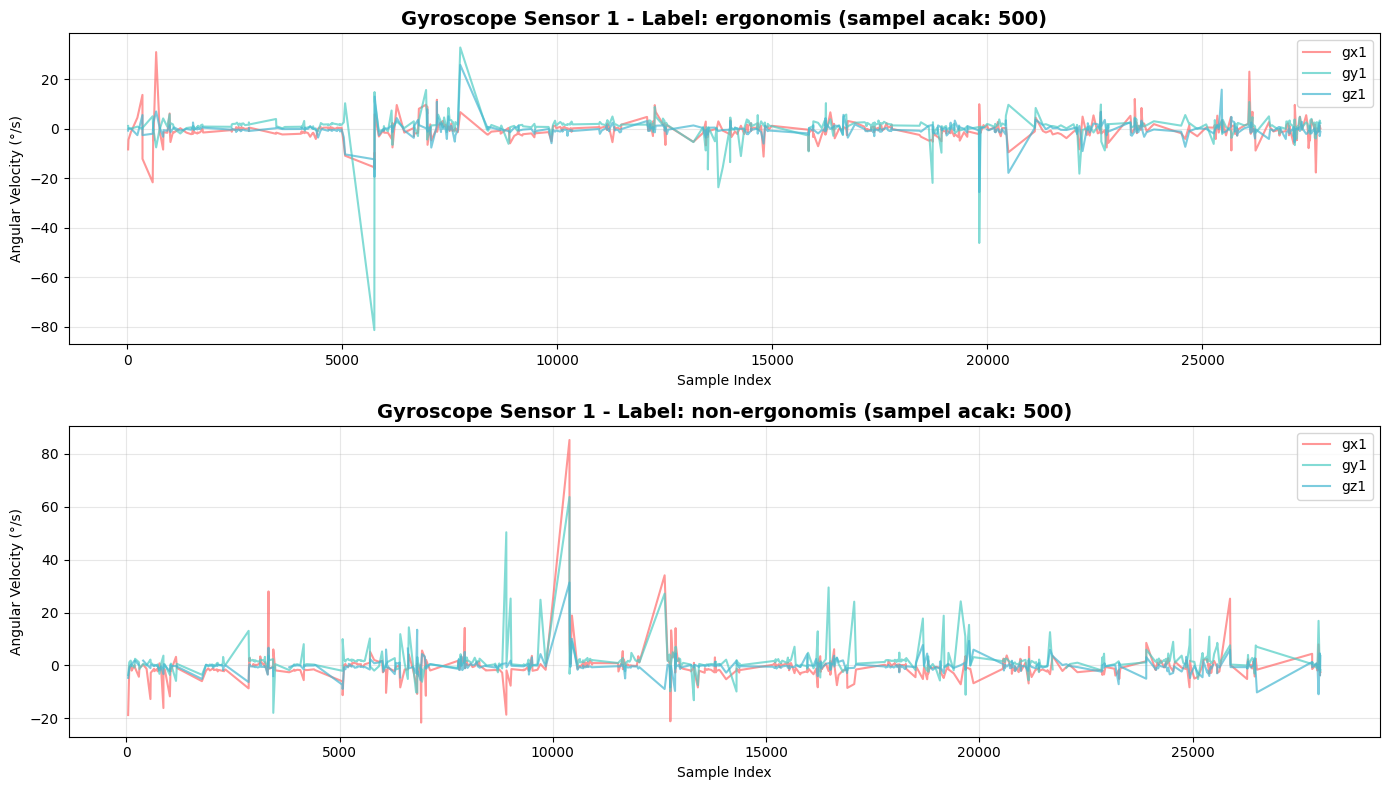


Membuat visualisasi Gyroscope Sensor 2...


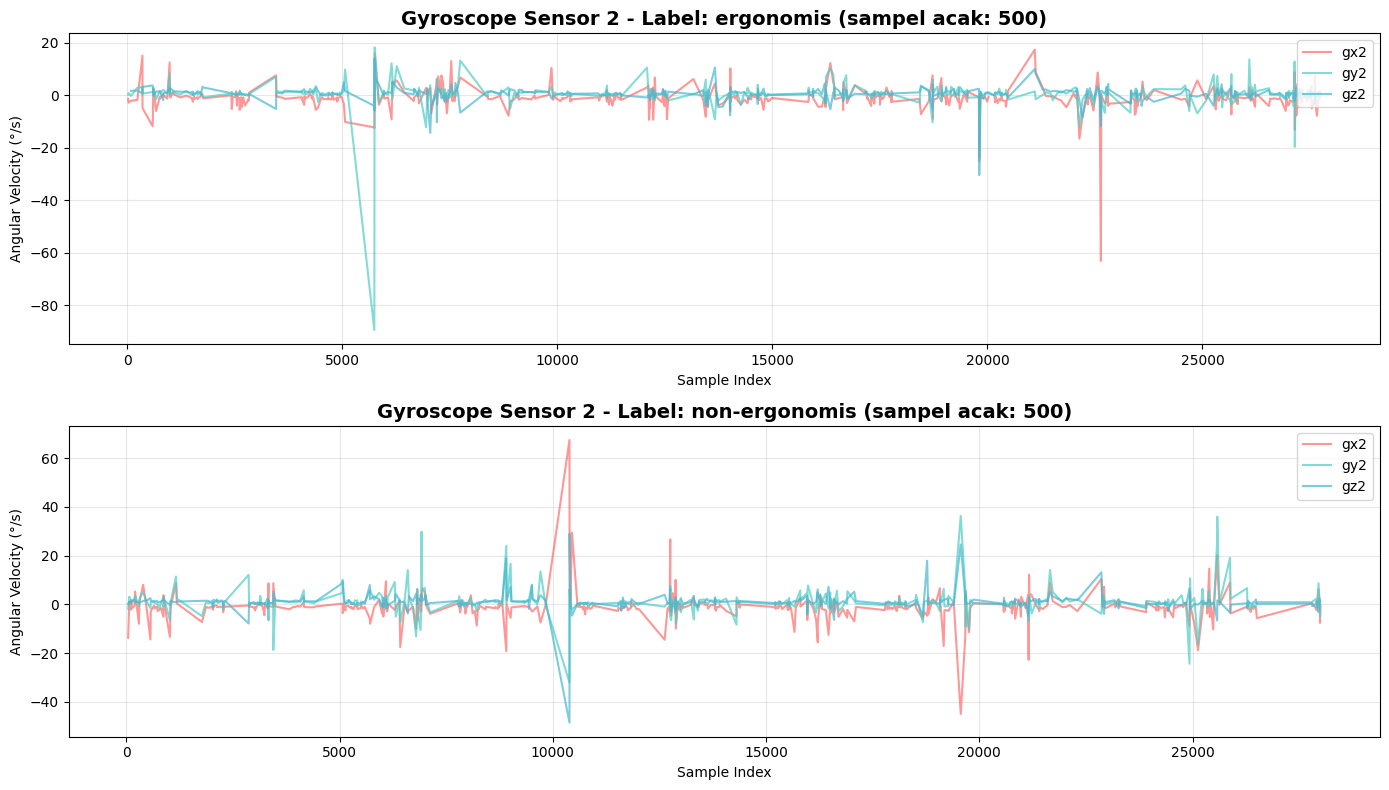

In [10]:
# Opsi A: Dari folder berisi file CSV
df_all = gabung_data_dari_folder('/content/drive/MyDrive/tga_anisa')

# Opsi B: Dari beberapa DataFrame yang sudah ada
# df_all = gabung_dataframe([df1, df2, df3])

grouped = analisis_per_label(df_all, label_col='label')

# Akselerometer Sensor 1
plot_accel_per_label(df_all, label_col='label', sensor_id=1, max_samples=500)

# Akselerometer Sensor 2
plot_accel_per_label(df_all, label_col='label', sensor_id=2, max_samples=500)

# Gyroscope Sensor 1
plot_gyro_per_label(df_all, label_col='label', sensor_id=1, max_samples=500)

# Gyroscope Sensor 2
plot_gyro_per_label(df_all, label_col='label', sensor_id=2, max_samples=500)

# Akselerometer Sensor 1
plot_accel_per_label(df_all, label_col='label', sensor_id=1, max_samples=500)

# Akselerometer Sensor 2
plot_accel_per_label(df_all, label_col='label', sensor_id=2, max_samples=500)

# Gyroscope Sensor 1
plot_gyro_per_label(df_all, label_col='label', sensor_id=1, max_samples=500)

# Gyroscope Sensor 2
plot_gyro_per_label(df_all, label_col='label', sensor_id=2, max_samples=500)

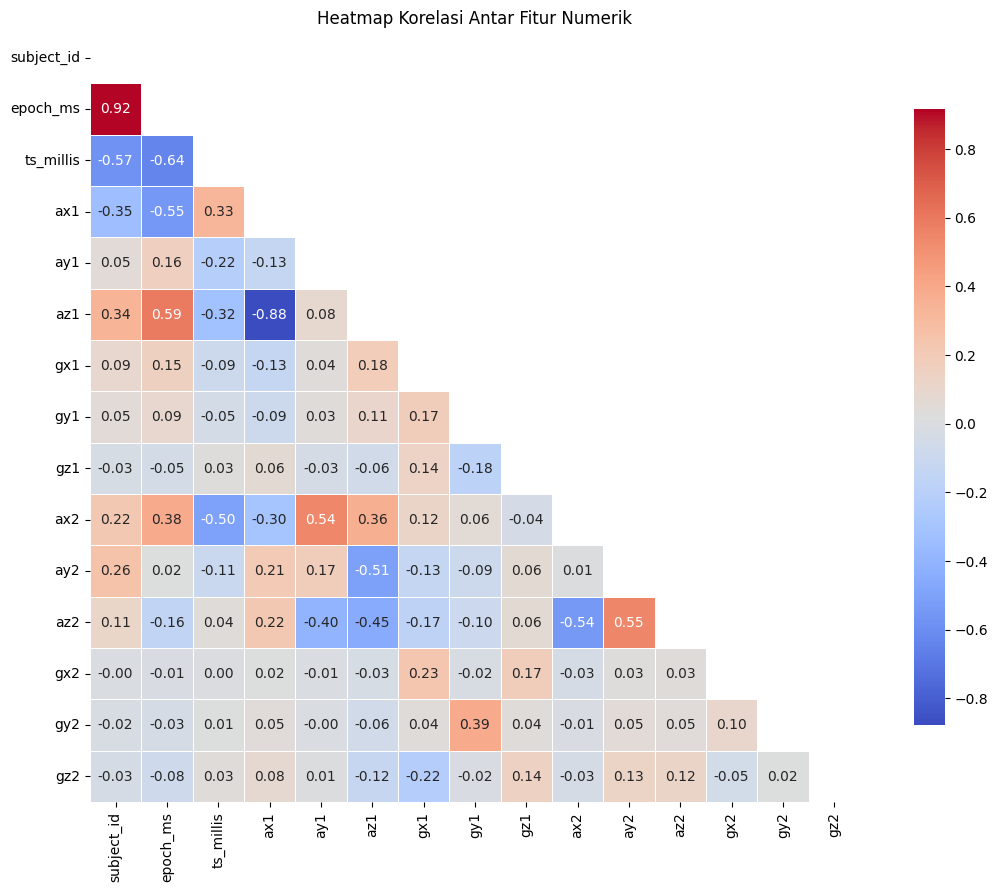


⚠️ Pasangan fitur dengan korelasi sangat tinggi (>|0.9|):
   subject_id & epoch_ms : 0.916


In [11]:
# Cell EDA 4: Heatmap korelasi (hanya kolom numerik)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
                linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
    plt.title('Heatmap Korelasi Antar Fitur Numerik')
    plt.show()

    # Cari pasangan fitur dengan korelasi tinggi (>0.9 atau <-0.9)
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if abs(corr.iloc[i, j]) > 0.9:
                high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
    if high_corr:
        print("\n⚠️ Pasangan fitur dengan korelasi sangat tinggi (>|0.9|):")
        for pair in high_corr:
            print(f"   {pair[0]} & {pair[1]} : {pair[2]:.3f}")
    else:
        print("\n✅ Tidak ada pasangan fitur dengan korelasi >|0.9|.")
else:
    print("Tidak cukup kolom numerik untuk korelasi.")


## Analisi Variabel Target

ANALISIS TARGET: 'label'
Jumlah unik value: 2

Value counts:
label
ergonomis        14678
non-ergonomis    13376
Name: count, dtype: int64


/tmp/ipykernel_1103/622614518.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[target_col], order=df[target_col].value_counts().index, palette='Set2')


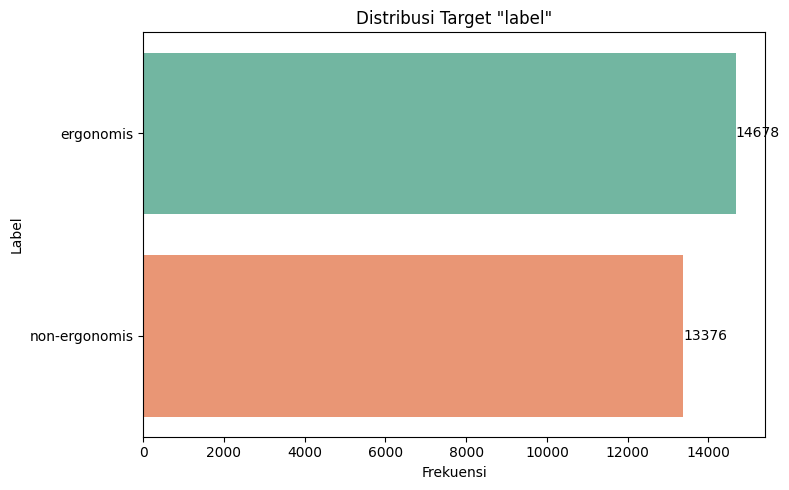


Rasio kelas minoritas/mayoritas: 0.911
✅ Dataset cukup seimbang.


In [12]:
# Cell EDA 5: Analisis target (kolom 'label')
target_col = 'label'  # sesuai dengan data Anda

if target_col in df.columns:
    print("="*50)
    print(f"ANALISIS TARGET: '{target_col}'")
    print("="*50)

    print("Jumlah unik value:", df[target_col].nunique())
    print("\nValue counts:")
    print(df[target_col].value_counts())

    # Visualisasi distribusi target
    plt.figure(figsize=(8, 5))
    sns.countplot(y=df[target_col], order=df[target_col].value_counts().index, palette='Set2')
    plt.title(f'Distribusi Target "{target_col}"')
    plt.xlabel('Frekuensi')
    plt.ylabel('Label')
    for i, v in enumerate(df[target_col].value_counts().values):
        plt.text(v + 2, i, str(v), va='center')
    plt.tight_layout()
    plt.show()

    # Cek apakah target seimbang (untuk klasifikasi)
    counts = df[target_col].value_counts()
    min_class = counts.min()
    max_class = counts.max()
    imbalance_ratio = min_class / max_class
    print(f"\nRasio kelas minoritas/mayoritas: {imbalance_ratio:.3f}")
    if imbalance_ratio < 0.2:
        print("⚠️ Dataset tidak seimbang (imbalance). Pertimbangkan teknik resampling nanti.")
    else:
        print("✅ Dataset cukup seimbang.")
else:
    print(f"Kolom target '{target_col}' tidak ditemukan. Silakan cek nama kolom.")

# Cleaning Data

## Handle Missing Values & Hapus Kolom Non-Fitur

In [13]:
# Cell Cleaning 1: Tangani missing values dan hapus kolom yang tidak diperlukan
df_clean = df.copy()

# 1. Hapus kolom yang tidak diperlukan (identitas, waktu, metadata)
# Keep 'source_file' because it's needed for LOPO splitting
cols_to_drop = ['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis', 'datetime','mpu_id']
cols_exist = [c for c in cols_to_drop if c in df_clean.columns]
df_clean.drop(columns=cols_exist, inplace=True)
print(f"Kolom yang dihapus: {cols_exist}")
print(f"Kolom tersisa: {df_clean.columns.tolist()}")

# 2. Tangani missing values
print("\nMissing values sebelum handling:")
print(df_clean.isnull().sum())

# Identify numerical columns for imputation
numerical_cols = df_clean.select_dtypes(include=np.number).columns
# Fill NaN values in numerical columns with their mean
for col in numerical_cols:
    if df_clean[col].isnull().any():
        col_mean = df_clean[col].mean()
        df_clean[col].fillna(col_mean, inplace=True)
        print(f"Filled NaN in '{col}' with mean: {col_mean:.4f}")

# Drop any remaining rows with NaNs (e.g., if non-numeric columns had NaNs, though 'label' and 'source_file' seem clean)
initial_rows = len(df_clean)
df_clean.dropna(inplace=True)
if len(df_clean) < initial_rows:
    print(f"Dihapus {initial_rows - len(df_clean)} baris dengan missing values setelah imputasi.")

print(f"\nSetelah handling missing values, jumlah baris: {len(df_clean)}")

# Cek ulang missing values
print("\nMissing values setelah handling:")
print(df_clean.isnull().sum())

Kolom yang dihapus: ['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis']
Kolom tersisa: ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'label', 'source_file']

Missing values sebelum handling:
ax1             0
ay1            14
az1             2
gx1            46
gy1            34
gz1            90
ax2             0
ay2            21
az2            11
gx2            35
gy2            67
gz2            46
label           0
source_file     0
dtype: int64
Filled NaN in 'ay1' with mean: 0.0215
Filled NaN in 'az1' with mean: 0.5278
Filled NaN in 'gx1' with mean: -0.6999
Filled NaN in 'gy1' with mean: 1.0897
Filled NaN in 'gz1' with mean: -0.3149
Filled NaN in 'ay2' with mean: -0.0072
Filled NaN in 'az2' with mean: 0.2526
Filled NaN in 'gx2' with mean: -1.1922
Filled NaN in 'gy2' with mean: 0.6746
Filled NaN in 'gz2' with mean: 0.8810

Setelah handling missing values, jumlah baris: 28054

Missing values setelah handling:
ax1            0
ay1 

/tmp/ipykernel_1103/1167003148.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(col_mean, inplace=True)


## Encoding Target Label

In [14]:
import pandas as pd
import numpy as np

# Bersihkan label terlebih dahulu: hapus spasi, lowercase
df_clean['label_clean'] = df_clean['label'].astype(str).str.strip().str.lower()

# Hapus baris di mana 'label_clean' adalah string kosong
# Ini menangani kasus seperti "    " yang menjadi ""
initial_rows = len(df_clean)
df_clean = df_clean[df_clean['label_clean'] != ''].copy() # Explicitly create a copy
if len(df_clean) < initial_rows:
    print(f"Dihapus {initial_rows - len(df_clean)} baris dengan label kosong setelah pembersihan.")

print(f"Unique values in 'label_clean' before mapping: {df_clean['label_clean'].unique()}")

# Mapping yang konsisten (pastikan nilai persis)
label_mapping = {'ergonomis': 1, 'non-ergonomis': 0}
print(f"Keys in label_mapping: {list(label_mapping.keys())}")

# Gunakan map
df_clean['label_encoded'] = df_clean['label_clean'].map(label_mapping)

# Validasi: tidak boleh ada NaN
# Re-enable the check, but modify the error message to be more informative
if df_clean['label_encoded'].isna().any():
    problematic = df_clean[df_clean['label_encoded'].isna()]['label_clean'].unique()
    raise ValueError(f"Found unmapped labels: {problematic}. Please check label_mapping.")

# Hapus kolom bantu jika perlu
df_clean.drop(columns=['label_clean'], inplace=True)

print("Distribusi target encoded:")
print(df_clean['label_encoded'].value_counts())

X = df_clean.drop(columns=['label', 'label_encoded'])
y = df_clean['label_encoded']

Unique values in 'label_clean' before mapping: ['ergonomis' 'non-ergonomis']
Keys in label_mapping: ['ergonomis', 'non-ergonomis']
Distribusi target encoded:
label_encoded
1    14678
0    13376
Name: count, dtype: int64


In [15]:
# Pisahkan kolom grup subjek dari fitur
# 'source_file' berisi nama file CSV per subjek
subject_col = 'source_file'

# --- Debugging prints ---
print(f"Shape of df_clean before group assignment in NH8u8_dsIM64: {df_clean.shape}")
print(f"Columns of df_clean: {df_clean.columns.tolist()}")

if subject_col in df_clean.columns:
    print(f"'{subject_col}' column exists in df_clean.")
    print(f"Data type of '{subject_col}': {df_clean[subject_col].dtype}")
    print(f"Number of non-null values in '{subject_col}': {df_clean[subject_col].count()}")
    print(f"Number of unique values in '{subject_col}': {df_clean[subject_col].nunique()}")
    unique_subjects = df_clean[subject_col].unique()
    print(f"Unique values in '{subject_col}': {unique_subjects}")
    if len(unique_subjects) > 5:
        print(f"First 5 unique values: {unique_subjects[:5].tolist()}")
    else:
        print(f"All unique values: {unique_subjects.tolist()}")
    print(f"First 5 values of '{subject_col}': {df_clean[subject_col].head().tolist()}")
    print(f"Last 5 values of '{subject_col}': {df_clean[subject_col].tail().tolist()}")
else:
    print(f"ERROR: '{subject_col}' column DOES NOT exist in df_clean at this point.")
    # Exit or raise error if column is truly missing, as this is a critical issue
# --- End debugging prints ---

groups = df_clean[subject_col].values          # array identitas subjek per baris
X      = df_clean.drop(columns=['label', 'label_encoded', subject_col])
y      = df_clean['label_encoded']

subjek_unik = np.unique(groups)
print(f"Total subjek: {len(subjek_unik)}")
print(f"Daftar subjek: {subjek_unik}")

Shape of df_clean before group assignment in NH8u8_dsIM64: (28054, 15)
Columns of df_clean: ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'label', 'source_file', 'label_encoded']
'source_file' column exists in df_clean.
Data type of 'source_file': object
Number of non-null values in 'source_file': 28054
Number of unique values in 'source_file': 21
Unique values in 'source_file': ['gabungan_mpu_alifi.csv' 'gabungan_mpu_fathur.csv'
 'gabungan_mpu_kelvin.csv' 'gabungan_mpu_alam.csv' 'gabungan_mpu_dina.csv'
 'gabungan_mpu_nisa.csv' 'gabungan_mpu_sofi.csv' 'gabungan_mpu_sutri.csv'
 'gabungan_mpu_ayuk.csv' 'gabungan_mpu_dika.csv' 'gabungan_mpu_arlin.csv'
 'gabungan_mpu_nahwa.csv' 'gabungan_mpu_fatim.csv'
 'gabungan_mpu_adnin.csv' 'gabungan_mpu_padli.csv'
 'gabungan_mpu_sultan.csv' 'gabungan_mpu_fateh.csv'
 'gabungan_mpu_yunda.csv' 'gabungan_mpu_rina.csv' 'gabungan_mpu_brian.csv'
 'gabungan_mpu_ilmi.csv']
First 5 unique values: ['gabungan_mpu_alifi.csv',

## Penanganan Outlier

Frekuensi sampling yang digunakan: 5.00 Hz

Kolom sensor yang dianalisis: ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2']


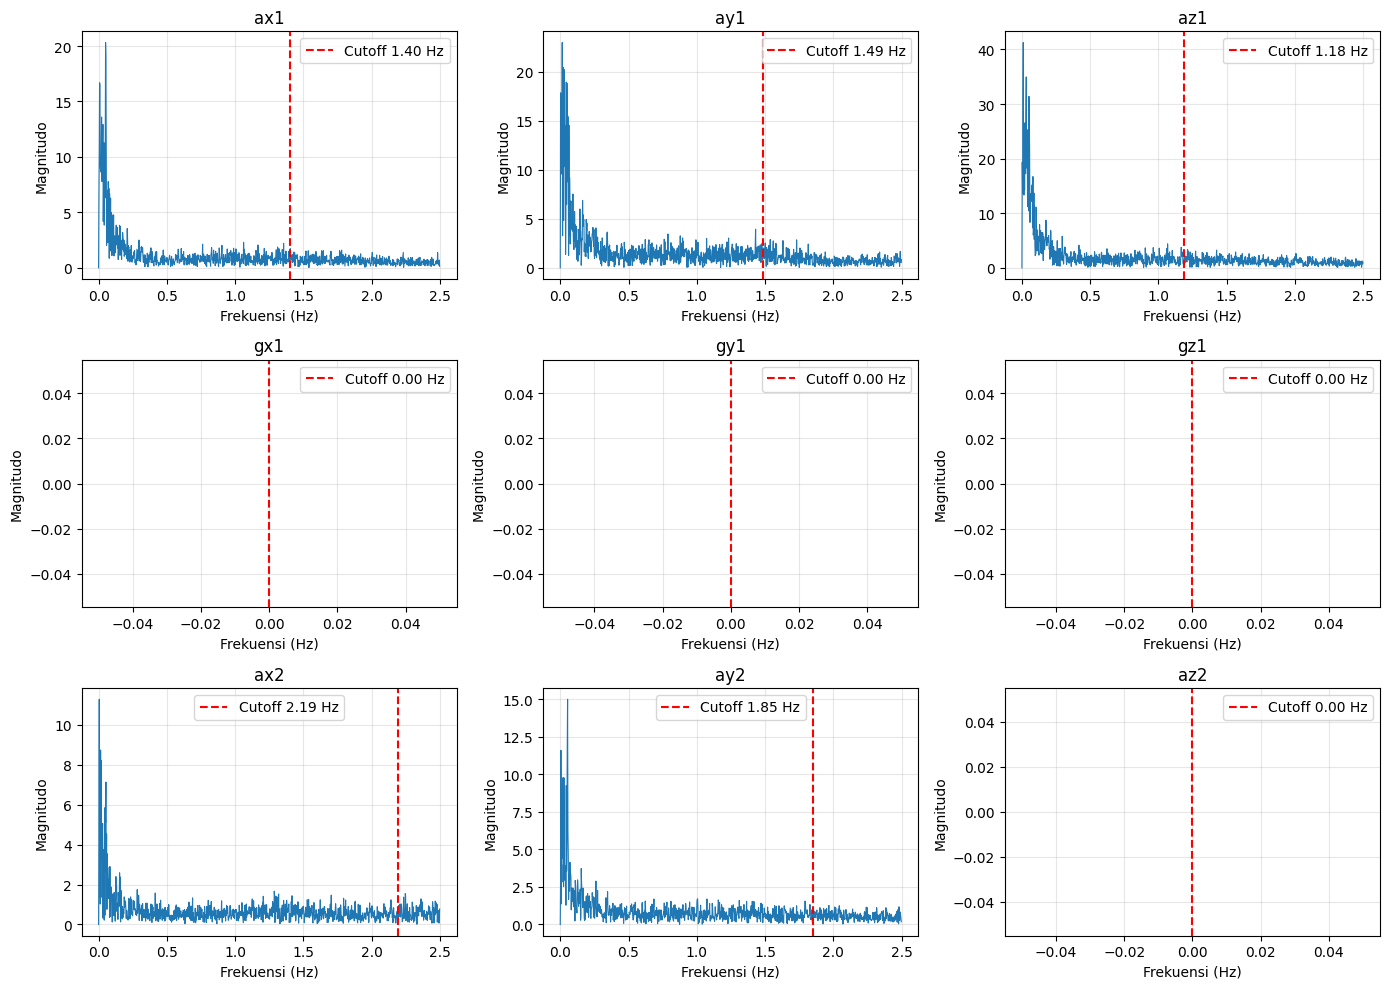


=== Rekomendasi Parameter Filter ===
Butterworth low-pass cutoff: berdasarkan FFT, disarankan sekitar 1.18 Hz
   (rentang: 0.00 - 2.19 Hz)
Kalman filter:
   Measurement variance (R) ≈ 2.963444 (gunakan nilai sekitar ini)
   Process variance (Q) ≈ 0.154396 (gunakan nilai sekitar ini)


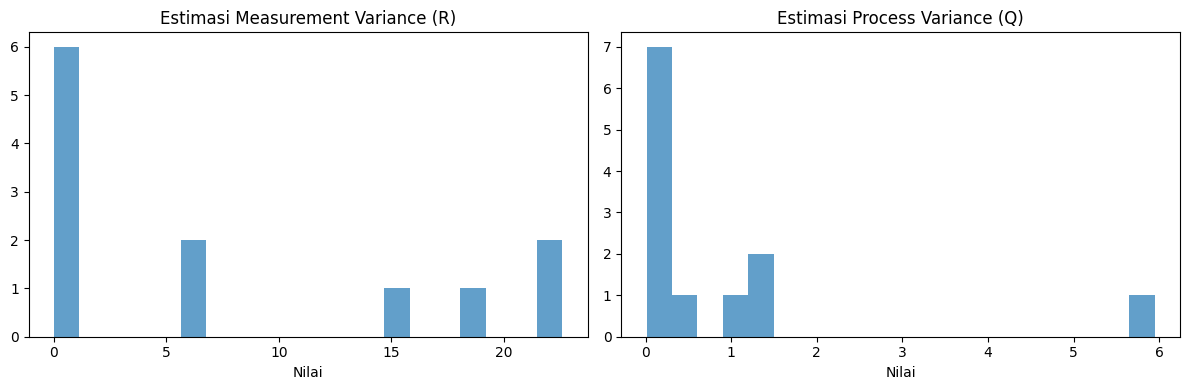

In [16]:
# Cell Analisis Frekuensi dan Noise untuk Filter (sebelum outlier detection)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import periodogram

# ====================================================
# 1. Hitung frekuensi sampling dari timestamp
# ====================================================
# Hitung sampling frequency dari timestamp (sama seperti di sel FFT)
if 'epoch_ms' in df.columns:
    timestamps = df['epoch_ms'].values
elif 'ts_millis' in df.columns:
    timestamps = df['ts_millis'].values
else:
    timestamps = np.arange(len(df))

diffs = np.diff(timestamps) / 1000.0  # dalam detik
median_dt = np.median(diffs)
sampling_freq = 1.0 / median_dt if median_dt > 0 else 50.0
print(f"Frekuensi sampling yang digunakan: {sampling_freq:.2f} Hz")

# ====================================================
# 2. Pilih kolom sensor numerik (abaikan label, subject_id, dll)
# ====================================================
ignore_cols = ['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis',
               'source_file', 'datetime', 'label', 'label_encoded']
sensor_cols = [c for c in df.columns if c not in ignore_cols and np.issubdtype(df[c].dtype, np.number)]

print(f"\nKolom sensor yang dianalisis: {sensor_cols}")

# ====================================================
# 3. Analisis FFT untuk setiap sensor (ambil sampel 2048 points untuk efisiensi)
# ====================================================
n_fft = min(2048, len(df))
freqs = fftfreq(n_fft, d=median_dt)
pos_mask = freqs > 0

# Simpan rekomendasi cutoff untuk setiap sensor
cutoff_recommendations = {}

plt.figure(figsize=(14, 10))
for i, col in enumerate(sensor_cols[:9]):  # maksimal 9 subplot
    data = df[col].values[:n_fft]
    # Detrend sederhana
    data = data - np.mean(data)
    # FFT
    fft_vals = np.abs(fft(data))[:n_fft//2]
    f = freqs[:n_fft//2]

    # Cari frekuensi di mana 95% energi berada
    psd = fft_vals**2
    cumulative_energy = np.cumsum(psd) / np.sum(psd)
    cutoff_idx = np.searchsorted(cumulative_energy, 0.95)
    cutoff_freq = f[cutoff_idx] if cutoff_idx < len(f) else f[-1]
    cutoff_recommendations[col] = cutoff_freq

    plt.subplot(3, 3, i+1)
    plt.plot(f, fft_vals, linewidth=0.8)
    plt.axvline(cutoff_freq, color='r', linestyle='--', label=f'Cutoff {cutoff_freq:.2f} Hz')
    plt.title(f'{col}')
    plt.xlabel('Frekuensi (Hz)')
    plt.ylabel('Magnitudo')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# ====================================================
# 4. Estimasi noise variance (R) dan process variance (Q) untuk Kalman
# ====================================================
# Metode: gunakan differencing orde pertama untuk estimasi noise
# Asumsi: sinyal = state + noise, state berubah lambat
noise_vars = []
process_vars = []

for col in sensor_cols:
    data = df[col].dropna().values
    if len(data) < 10:
        continue
    # Estimasi noise: variansi dari high-pass residual (selisih orde pertama)
    diff = np.diff(data)
    # Asumsikan perubahan state lambat, noise mendominasi pada diff
    # Estimasi R = variansi dari diff / 2 (karena diff = noise_t+1 - noise_t)
    R_est = np.var(diff) / 2.0
    # Estimasi Q: variansi dari perubahan state yang dihaluskan (low-pass)
    # Alternatif: Q = variansi dari perubahan sinyal setelah smoothing
    # Di sini kita gunakan variansi dari sinyal original dikurangi estimasi noise
    Q_est = max(0.01, np.var(data) - R_est)  # ensure positive
    noise_vars.append(R_est)
    process_vars.append(Q_est)

# Rata-rata rekomendasi
median_R = np.median(noise_vars) if noise_vars else 1e-2
median_Q = np.median(process_vars) if process_vars else 1e-5

print(f"\n=== Rekomendasi Parameter Filter ===")
print(f"Butterworth low-pass cutoff: berdasarkan FFT, disarankan sekitar {np.median(list(cutoff_recommendations.values())):.2f} Hz")
print(f"   (rentang: {min(cutoff_recommendations.values()):.2f} - {max(cutoff_recommendations.values()):.2f} Hz)")
print(f"Kalman filter:")
print(f"   Measurement variance (R) ≈ {median_R:.6f} (gunakan nilai sekitar ini)")
print(f"   Process variance (Q) ≈ {median_Q:.6f} (gunakan nilai sekitar ini)")

# ====================================================
# 5. Visualisasi distribusi noise dan sinyal (opsional)
# ====================================================
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.hist(noise_vars, bins=20, alpha=0.7)
plt.title('Estimasi Measurement Variance (R)')
plt.xlabel('Nilai')
plt.subplot(1,2,2)
plt.hist(process_vars, bins=20, alpha=0.7)
plt.title('Estimasi Process Variance (Q)')
plt.xlabel('Nilai')
plt.tight_layout()
plt.show()

# Preprocessing

## Split Data Train-Test

In [17]:
# # Cell Preprocessing 1: Split data menjadi train dan test
# from sklearn.model_selection import train_test_split

# split_idx = int(len(X) * 0.8)
# X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
# y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# print(f"Train: {X_train.shape}, Test: {X_test.shape}")
# print("Distribusi y_train:", y_train.value_counts(normalize=True).to_dict())
# print("Distribusi y_test:", y_test.value_counts(normalize=True).to_dict())

## Filtering

In [18]:
# Cell Preprocessing: Filtering (Kalman & Butterworth)
# Place this cell BEFORE outlier detection (after cleaning, before windowing)

from scipy.signal import butter, filtfilt, lfilter
import numpy as np

def butterworth_filter_causal(data, cutoff, fs, order=4, btype='low'):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype=btype, analog=False)
    # lfilter -> causal (hanya data masa lalu)
    return lfilter(b, a, data)

def kalman_filter_1d(data, process_variance=1e-5, measurement_variance=1e-2):
    """
    Simple 1D Kalman filter for smoothing.

    Parameters:
    data (array): 1D signal
    process_variance (float): Q - process noise covariance
    measurement_variance (float): R - measurement noise covariance

    Returns:
    filtered (array): filtered signal
    """
    n = len(data)
    filtered = np.zeros(n)
    # Initial state estimate and error covariance
    x_est = data[0]
    P_est = 1.0

    for i in range(n):
        # Prediction
        x_pred = x_est
        P_pred = P_est + process_variance

        # Update
        K = P_pred / (P_pred + measurement_variance)  # Kalman gain
        x_est = x_pred + K * (data[i] - x_pred)
        P_est = (1 - K) * P_pred
        filtered[i] = x_est

    return filtered

# ========== USER ADJUSTABLE PARAMETERS ==========
# --- Butterworth settings ---
use_butterworth = False         # Set False to skip
butter_cutoff = 5.0            # Cutoff frequency (Hz)
butter_order = 5               # Filter order

# --- Kalman settings ---
use_kalman = False              # Set False to skip
kalman_process_var = 0.001      # Process noise variance
kalman_measurement_var = 0.1  # Measurement noise variance

# ================================================

# # Apply filters to each numeric column (excluding label)
# numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
# # Note: X here is the feature DataFrame after cleaning, before windowing (time series)

# if use_butterworth or use_kalman:
#     print("Menerapkan filter ke setiap kolom numerik...")
#     for col in numeric_cols:
#         data = X_train[col].values
#         if use_butterworth:
#             data = butterworth_filter_causal(data, butter_cutoff, sampling_freq, butter_order)
#         if use_kalman:
#             data = kalman_filter_1d(data, kalman_process_var, kalman_measurement_var)
#         X_train[col] = data
#     print("Filter selesai diterapkan.")
# else:
#     print("Tidak ada filter yang diterapkan.")


In [19]:
# # Cell Perbandingan Sebelum dan Sesudah Filtering (tanpa modifikasi data)

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ------------------------------------------------------------------
# # 1. Ambil data asli (sebelum filtering) dari df_clean
# #    Asumsi: df_clean masih berisi nilai sensor asli (belum difilter)
# #    dan X adalah DataFrame hasil filtering (sudah dimodifikasi)
# # ------------------------------------------------------------------
# # Kolom sensor yang digunakan dalam filtering (numeric_cols)
# numeric_cols = X_train.columns.tolist()  # karena X setelah filtering

# # Buat DataFrame asli dari df_clean hanya untuk kolom yang sama
# if 'df_clean' in globals():
#     original_data = df_clean[numeric_cols].copy()
#     print("Data asli (sebelum filtering) diambil dari df_clean.")
# else:
#     # fallback: jika df_clean tidak ada, coba gunakan X_original (jika ada)
#     if 'X_original' in globals():
#         original_data = X[numeric_cols].copy()
#         print("Data asli (sebelum filtering) diambil dari X_original.")
#     else:
#         raise NameError("Tidak ditemukan data asli (df_clean atau X_original).")

# # Data setelah filtering sudah ada di X
# filtered_data = X[numeric_cols].copy()
# print(f"Data setelah filtering diambil dari X (shape: {filtered_data.shape})")

# # ------------------------------------------------------------------
# # 2. Pilih beberapa kolom sensor untuk visualisasi (maksimal 6)
# # ------------------------------------------------------------------
# sample_cols = numeric_cols[:6]  # ambil 6 kolom pertama
# n_cols = len(sample_cols)

# # ------------------------------------------------------------------
# # 3. Plot perbandingan sinyal (500 sampel pertama)
# # ------------------------------------------------------------------
# fig, axes = plt.subplots(n_cols, 2, figsize=(14, 3*n_cols))
# if n_cols == 1:
#     axes = axes.reshape(1, -1)

# for i, col in enumerate(sample_cols):
#     # Sinyal asli dan setelah filter (500 poin pertama)
#     orig = original_data[col].values[:500]
#     filt = filtered_data[col].values[:500]

#     # Plot sinyal asli
#     axes[i, 0].plot(orig, label='Original', alpha=0.6, linewidth=0.8)
#     axes[i, 0].set_title(f'{col} - Original (sebelum filter)')
#     axes[i, 0].set_xlabel('Sampel ke-')
#     axes[i, 0].set_ylabel('Nilai')
#     axes[i, 0].legend()
#     axes[i, 0].grid(True, alpha=0.3)

#     # Plot sinyal setelah filter
#     axes[i, 1].plot(filt, label='Filtered', color='orange', alpha=0.6, linewidth=0.8)
#     axes[i, 1].set_title(f'{col} - Setelah Filter (Butterworth+Kalman)')
#     axes[i, 1].set_xlabel('Sampel ke-')
#     axes[i, 1].set_ylabel('Nilai')
#     axes[i, 1].legend()
#     axes[i, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # ------------------------------------------------------------------
# # 4. Statistik ringkasan (mean, std, min, max) untuk semua kolom
# # ------------------------------------------------------------------
# stats_orig = original_data.describe().T[['mean', 'std', 'min', 'max']]
# stats_filt = filtered_data.describe().T[['mean', 'std', 'min', 'max']]

# # Gabungkan untuk perbandingan
# stats_comp = pd.DataFrame({
#     'mean_orig': stats_orig['mean'],
#     'mean_filt': stats_filt['mean'],
#     'std_orig': stats_orig['std'],
#     'std_filt': stats_filt['std'],
#     'min_orig': stats_orig['min'],
#     'min_filt': stats_filt['min'],
#     'max_orig': stats_orig['max'],
#     'max_filt': stats_filt['max']
# })

# print("\n=== PERBANDINGAN STATISTIK (seluruh kolom) ===")
# print(stats_comp.round(4))

# # Hitung persen perubahan standar deviasi (indikator penurunan noise)
# stats_comp['std_change_%'] = ((stats_comp['std_filt'] - stats_comp['std_orig']) / stats_comp['std_orig']) * 100
# print("\n=== PERSENTASE PERUBAHAN STANDAR DEVIASI ===")
# print(stats_comp['std_change_%'].round(2))

# # ------------------------------------------------------------------
# # 5. Visualisasi distribusi selisih (original - filtered) untuk menilai noise
# # ------------------------------------------------------------------
# fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# axes = axes.flatten()
# for idx, col in enumerate(sample_cols):
#     diff = original_data[col].values - filtered_data[col].values
#     axes[idx].hist(diff, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
#     axes[idx].set_title(f'{col} - Selisih (Original - Filtered)')
#     axes[idx].set_xlabel('Selisih')
#     axes[idx].set_ylabel('Frekuensi')
#     axes[idx].grid(True, alpha=0.3)
# # Matikan axis yang tidak terpakai
# for j in range(len(sample_cols), len(axes)):
#     axes[j].set_visible(False)
# plt.tight_layout()
# plt.show()

# # ------------------------------------------------------------------
# # 6. Ringkasan pengaruh filtering (opsional)
# # ------------------------------------------------------------------
# print("\n=== KESIMPULAN AWAL ===")
# print(f"Rata-rata perubahan standar deviasi: {stats_comp['std_change_%'].mean():.2f}%")
# if stats_comp['std_change_%'].mean() < 0:
#     print("Filtering secara umum mengurangi variabilitas sinyal (noise berkurang).")
# else:
#     print("Filtering tidak secara konsisten mengurangi variabilitas; periksa parameter.")

## Ektraksi fitur


In [20]:
# import numpy as np
# import pandas as pd

# def add_derived_features(X_df):
#     """
#     Fitur turunan per baris — dihitung instan tanpa buffer.
#     Gyroscope dikomentari, hanya menggunakan Akselerometer, Pressure, dan Altitude.
#     """
#     X = X_df.copy()

#     # Pastikan kolom sensor numerik (Gyroscope dikomentari)
#     sensor_numeric_cols = [
#         'ax1', 'ay1', 'az1',
#         # 'gx1', 'gy1', 'gz1',  # <--- DIKOMENTARI (Tidak digunakan)
#         'ax2', 'ay2', 'az2',
#         # 'gx2', 'gy2', 'gz2',  # <--- DIKOMENTARI (Tidak digunakan)
#         'pressure_hpa', 'altitude_m'
#     ]

#     for col in sensor_numeric_cols:
#         if col in X.columns:
#             X[col] = pd.to_numeric(X[col], errors='coerce')
#             X[col] = X[col].fillna(0)
#             X[col] = X[col].replace([np.inf, -np.inf], 0)

#     # Magnitudo akselerometer (intensitas gerakan keseluruhan)
#     if all(c in X.columns for c in ['ax1','ay1','az1']):
#         X['acc_mag1'] = np.sqrt(X['ax1']**2 + X['ay1']**2 + X['az1']**2)
#     if all(c in X.columns for c in ['ax2','ay2','az2']):
#         X['acc_mag2'] = np.sqrt(X['ax2']**2 + X['ay2']**2 + X['az2']**2)

#     # Magnitudo gyroscope (DIKOMENTARI)
#     # if all(c in X.columns for c in ['gx1','gy1','gz1']):
#     #     X['gyro_mag1'] = np.sqrt(X['gx1']**2 + X['gy1']**2 + X['gz1']**2)
#     # if all(c in X.columns for c in ['gx2','gy2','gz2']):
#     #     X['gyro_mag2'] = np.sqrt(X['gx2']**2 + X['gy2']**2 + X['gz2']**2)

#     # Selisih antar sensor (Hanya 'a', 'g' dikomentari agar tidak membuat diff_gx, dll)
#     for axis in ['x','y','z']:
#         for s in ['a']: # ['a', 'g'] -> 'g' dikomentari
#             c1, c2 = f'{s}{axis}1', f'{s}{axis}2'
#             if c1 in X.columns and c2 in X.columns:
#                 X[f'diff_{s}{axis}'] = X[c1] - X[c2]

#     # Sudut kemiringan / tilt (menggunakan akselerometer)
#     if all(c in X.columns for c in ['ax1','ay1','az1']):
#         X['roll1']  = np.arctan2(X['ay1'], np.sqrt(X['ax1']**2 + X['az1']**2) + 1e-9)
#         X['pitch1'] = np.arctan2(-X['ax1'], np.sqrt(X['ay1']**2 + X['az1']**2) + 1e-9)
#     if all(c in X.columns for c in ['ax2','ay2','az2']):
#         X['roll2']  = np.arctan2(X['ay2'], np.sqrt(X['ax2']**2 + X['az2']**2) + 1e-9)
#         X['pitch2'] = np.arctan2(-X['ax2'], np.sqrt(X['ay2']**2 + X['az2']**2) + 1e-9)

#     # Beda sudut antar sensor (indikator ketidakselarasan postur)
#     if all(c in X.columns for c in ['roll1','roll2']):
#         X['diff_roll']  = X['roll1'] - X['roll2']
#         X['diff_pitch'] = X['pitch1'] - X['pitch2']

#     return X


# def add_rolling_features(X_df, n=3):
#     """
#     Rolling pendek HANYA pada fitur kunci.
#     N=3 di 5Hz = 0.6 detik delay.
#     Gyroscope dikomentari.
#     """
#     X = X_df.copy()

#     # Pilih hanya fitur yang paling relevan (gyro_mag dikomentari)
#     key_cols = [c for c in ['acc_mag1','acc_mag2',
#                             # 'gyro_mag1','gyro_mag2', # <--- DIKOMENTARI
#                             'roll1','pitch1','diff_roll','diff_pitch']
#                 if c in X.columns]

#     for col in key_cols:
#         X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)
#         X[f'{col}_rm{n}'] = X[col].rolling(n, min_periods=1).mean()
#         X[f'{col}_rs{n}'] = X[col].rolling(n, min_periods=1).std().fillna(0)

#     return X


# def add_rolling_per_subject(X_df, y_df, groups_arr, n=3):
#     """Rolling dihitung ulang per subjek agar tidak melewati batas."""
#     parts_X, parts_y = [], []
#     for subj in np.unique(groups_arr):
#         mask = groups_arr == subj
#         X_s = X_df[mask].copy()
#         X_s = add_rolling_features(X_s, n=n)
#         parts_X.append(X_s)
#         parts_y.append(y_df[mask])

#     return pd.concat(parts_X).reset_index(drop=True), \
#            pd.concat(parts_y).reset_index(drop=True)

###time window

In [21]:
import numpy as np
import pandas as pd

def add_derived_features(X_df):
    """
    Fitur turunan per baris — dihitung instan tanpa buffer.
    Gyroscope dikomentari, hanya menggunakan Akselerometer, Pressure, dan Altitude.
    """
    X = X_df.copy()

    # Pastikan kolom sensor numerik (Gyroscope dikomentari)
    sensor_numeric_cols = [
        'ax1', 'ay1', 'az1',
        'gx1', 'gy1', 'gz1',  # <--- DIKOMENTARI (Tidak digunakan)
        'ax2', 'ay2', 'az2',
        'gx2', 'gy2', 'gz2',  # <--- DIKOMENTARI (Tidak digunakan)
        'pressure_hpa', 'altitude_m'
    ]

    for col in sensor_numeric_cols:
        if col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')
            X[col] = X[col].fillna(0)
            X[col] = X[col].replace([np.inf, -np.inf], 0)

    # Magnitudo akselerometer (intensitas gerakan keseluruhan)
    if all(c in X.columns for c in ['ax1','ay1','az1']):
        X['acc_mag1'] = np.sqrt(X['ax1']**2 + X['ay1']**2 + X['az1']**2)
    if all(c in X.columns for c in ['ax2','ay2','az2']):
        X['acc_mag2'] = np.sqrt(X['ax2']**2 + X['ay2']**2 + X['az2']**2)

    # Selisih antar sensor (Hanya 'a')
    for axis in ['x','y','z']:
        for s in ['a']: # 'g' dikomentari
            c1, c2 = f'{s}{axis}1', f'{s}{axis}2'
            if c1 in X.columns and c2 in X.columns:
                X[f'diff_{s}{axis}'] = X[c1] - X[c2]

    # Sudut kemiringan / tilt (menggunakan akselerometer)
    if all(c in X.columns for c in ['ax1','ay1','az1']):
        X['roll1']  = np.arctan2(X['ay1'], np.sqrt(X['ax1']**2 + X['az1']**2) + 1e-9)
        X['pitch1'] = np.arctan2(-X['ax1'], np.sqrt(X['ay1']**2 + X['az1']**2) + 1e-9)
    if all(c in X.columns for c in ['ax2','ay2','az2']):
        X['roll2']  = np.arctan2(X['ay2'], np.sqrt(X['ax2']**2 + X['az2']**2) + 1e-9)
        X['pitch2'] = np.arctan2(-X['ax2'], np.sqrt(X['ay2']**2 + X['az2']**2) + 1e-9)

    # Beda sudut antar sensor
    if all(c in X.columns for c in ['roll1','roll2']):
        X['diff_roll']  = X['roll1'] - X['roll2']
        X['diff_pitch'] = X['pitch1'] - X['pitch2']

    return X

def add_rolling_features(X_df, n=3):
    """
    Rolling pendek HANYA pada fitur kunci.
    N=3 di 5Hz = 0.6 detik delay.
    Gyroscope dikomentari.
    """
    X = X_df.copy()

    # Pilih hanya fitur yang paling relevan (gyro_mag dikomentari)
    key_cols = [c for c in ['acc_mag1','acc_mag2',
                            'roll1','pitch1','diff_roll','diff_pitch']
                if c in X.columns]

    for col in key_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)
        X[f'{col}_rm{n}'] = X[col].rolling(n, min_periods=1).mean()
        X[f'{col}_rs{n}'] = X[col].rolling(n, min_periods=1).std().fillna(0)

    return X

def create_windowed_features(X_df, y_series, window_size=25, step_size=25, rolling_n=3):
    """
    Membagi data menjadi time window dan melakukan agregasi fitur (mean, std, min, max).
    Dilakukan per potongan data agar tidak ada leakage antar subjek.

    Perubahan baru:
    - Menambahkan fitur turunan (derived features) seperti magnitudo akselerometer, sudut tilt, dll.
    - Menambahkan fitur rolling mean & std pada fitur-fitur kunci dengan jendela rolling_n.

    Parameters:
    - window_size: Jumlah sampel per window (default 50)
    - step_size: Pergeseran window. step_size=25 berarti overlap 50%.
                 Gunakan step_size=50 untuk non-overlapping.
    - rolling_n: Ukuran jendela untuk rolling mean/std (default 3).
    """
    # 1. Hapus kolom gyroscope secara paksa jika masih ada
    cols_to_drop = [c for c in X_df.columns if c.startswith(('gx', 'gy', 'gz'))]
    X_clean = X_df.drop(columns=cols_to_drop, errors='ignore')
    # X_clean = X_df

    # # 2. Terapkan fitur turunan (derived features)
    # X_derived = add_derived_features(X_clean)

    # # 3. Terapkan fitur rolling pada fitur-fitur kunci
    X_rolling = X_clean

    # 4. Pastikan semua data numerik dan bersih
    X_processed = X_rolling.apply(pd.to_numeric, errors='coerce').fillna(0)
    X_processed = X_processed.reset_index(drop=True)
    y_clean = y_series.reset_index(drop=True)

    # Jika data lebih sedikit dari window_size, kembalikan kosong
    if len(X_processed) < window_size:
        return pd.DataFrame(), pd.Series()

    features_list = []
    labels_list = []

    # 5. Looping untuk membuat window
    for i in range(0, len(X_processed) - window_size + 1, step_size):
        window_X = X_processed.iloc[i : i + window_size]
        window_y = y_clean.iloc[i : i + window_size]

        agg_row = {}
        # 6. Agregasi: Mean, Std, Min, Max untuk setiap kolom sensor (termasuk fitur turunan & rolling)
        for col in X_processed.columns:
            agg_row[f'{col}_mean'] = window_X[col].mean()
            agg_row[f'{col}_std'] = np.nan_to_num(window_X[col].std()) # Mengatasi NaN pada std
            agg_row[f'{col}_min'] = window_X[col].min()
            agg_row[f'{col}_max'] = window_X[col].max()

        features_list.append(agg_row)

        # 7. Label untuk window = Modus (nilai yang paling sering muncul) di window tersebut
        labels_list.append(pd.Series(window_y).mode()[0])

    return pd.DataFrame(features_list), pd.Series(labels_list)

## Scaling Fitur

In [22]:
# # Cell Preprocessing 2: Standarisasi fitur numerik (StandardScaler)

# # Standarisasi fitur numerik (X_train)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_win)
# X_test_scaled = scaler.transform(X_test_win)

# # Konversi kembali ke DataFrame (opsional, untuk kemudahan)
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_win.columns, index=X_train_win.index)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_win.columns, index=X_test_win.index)

# print("Contoh statistik X_train_scaled:")
# display(X_train_scaled.describe())

# Modelling LOSO

## Training

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb


# ==============================================================================
# 2. PROSES LOPO CROSS-VALIDATION
# ==============================================================================

# --- Inisialisasi Variabel Penyimpanan Hasil ---
lopo_results = []
all_y_true   = []
all_y_pred   = []
conf_matrices = {}

# Global variables untuk hyperparameter tuning di fold terakhir
global X_train_hp, y_train_hp, X_test_hp, y_test_hp, scaler_hp, feature_names_hp
X_train_hp, y_train_hp, X_test_hp, y_test_hp, scaler_hp, feature_names_hp = None, None, None, None, None, None

xgb_final_model = None
X_train_last_fold_for_features = None

# Parameter Windowing (HANYA WINDOW_SIZE, tanpa STEP_SIZE)
WINDOW_SIZE = 30  # Ubah sesuai kebutuhan (misal 10, 30, 50)

print(f"Memulai LOPO dengan {len(subjek_unik)} fold...")
print(f"Konfigurasi Window: Size={WINDOW_SIZE} (Non-overlapping)")
print("="*60)

for fold_idx, test_subject in enumerate(subjek_unik):
    print(f"\nProcessing Fold {fold_idx+1}/{len(subjek_unik)} - Testing on: {test_subject}")

    # --- 1. Split berdasarkan subjek ---
    train_mask = groups != test_subject
    test_mask  = groups == test_subject

    X_train_current = X[train_mask].reset_index(drop=True)
    y_train_current = y[train_mask].reset_index(drop=True)
    X_test_current  = X[test_mask].reset_index(drop=True)
    y_test_current  = y[test_mask].reset_index(drop=True)

    if len(X_train_current) == 0 or len(X_test_current) == 0:
        print(f"  ⚠ Fold {fold_idx+1} skipped: Raw data split resulted in empty train/test for {test_subject}")
        continue

    # --- 2. TERAPKAN TIME WINDOW & AGREGASI (Non-overlapping) ---
    # Proses Train
    X_train_windowed, y_train_windowed = create_windowed_features(
        X_train_current, y_train_current, window_size=WINDOW_SIZE, step_size=WINDOW_SIZE
    )

    # Proses Test
    X_test_windowed, y_test_windowed = create_windowed_features(
        X_test_current, y_test_current, window_size=WINDOW_SIZE, step_size=WINDOW_SIZE
    )

    # Cek jika hasil windowing kosong (misal data test subjek terlalu sedikit < WINDOW_SIZE)
    if len(X_train_windowed) == 0 or len(X_test_windowed) == 0:
        print(f"  ⚠ Fold {fold_idx+1} skipped: Windowing resulted in empty data for {test_subject} (Data < {WINDOW_SIZE} samples)")
        continue

    X_train_processed = X_train_windowed
    y_train_processed = y_train_windowed
    X_test_processed  = X_test_windowed
    y_test_processed  = y_test_windowed

    # --- 3. Scaling (fit HANYA di train) ---
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_processed)
    X_test_scaled  = scaler.transform(X_test_processed)

    # --- 4. Training Model ---
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.6,
        colsample_bytree=1.0,
        reg_alpha=1,
        reg_lambda=10,
        gamma=0.5,
        eval_metric='logloss',
        min_child_weight=1,
        random_state=42,
        n_jobs=-1
    )
    # model = xgb.XGBClassifier(
    #     n_estimators=300,
    #     max_depth=8,
    #     learning_rate=0.05,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     reg_alpha=0.1,
    #     reg_lambda=1.0,
    #     eval_metric='logloss',
    #     random_state=42,
    #     n_jobs=-1
    # )
    model.fit(X_train_scaled, y_train_processed)

    # --- 5. Evaluasi fold ini ---
    y_pred = model.predict(X_test_scaled)
    cm_fold = confusion_matrix(y_test_processed, y_pred, labels=[0, 1])
    acc = accuracy_score(y_test_processed, y_pred)
    conf_matrices[test_subject] = cm_fold

    lopo_results.append({
        'fold'           : fold_idx + 1,
        'test_subject'   : test_subject,
        'n_train_samples': len(y_train_processed), # Ini adalah jumlah WINDOW
        'n_test_samples' : len(y_test_processed),
        'accuracy'       : acc
    })

    all_y_true.extend(y_test_processed.tolist())
    all_y_pred.extend(y_pred.tolist())

    print(f"  Fold {fold_idx+1:2d} | Test: {test_subject:<30s} | Acc: {acc:.4f} ({acc*100:.1f}%) | Train Windows: {len(y_train_processed)} | Test Windows: {len(y_test_processed)}")

    # Simpan model dan data train dari fold terakhir
    if fold_idx == len(subjek_unik) - 1:
        xgb_final_model = model
        X_train_last_fold_for_features = X_train_processed

        X_train_hp = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns)
        y_train_hp = y_train_processed
        X_test_hp = pd.DataFrame(X_test_scaled, columns=X_test_processed.columns)
        y_test_hp = y_test_processed
        scaler_hp = scaler
        feature_names_hp = X_train_processed.columns

print("="*60)

if not lopo_results:
    print("Warning: No folds were processed. 'all_y_true' and 'all_y_pred' are empty.")
else:
    results_df = pd.DataFrame(lopo_results)
    print("\nLOPO Summary:")
    print(results_df.to_string(index=False))
    print(f"\nRata-rata Akurasi LOPO: {results_df['accuracy'].mean():.4f} ({results_df['accuracy'].mean()*100:.1f}%)")

Memulai LOPO dengan 21 fold...
Konfigurasi Window: Size=30 (Non-overlapping)

Processing Fold 1/21 - Testing on: gabungan_mpu_adnin.csv
  Fold  1 | Test: gabungan_mpu_adnin.csv         | Acc: 1.0000 (100.0%) | Train Windows: 891 | Test Windows: 43

Processing Fold 2/21 - Testing on: gabungan_mpu_alam.csv
  Fold  2 | Test: gabungan_mpu_alam.csv          | Acc: 0.7959 (79.6%) | Train Windows: 885 | Test Windows: 49

Processing Fold 3/21 - Testing on: gabungan_mpu_alifi.csv
  Fold  3 | Test: gabungan_mpu_alifi.csv         | Acc: 0.6525 (65.3%) | Train Windows: 816 | Test Windows: 118

Processing Fold 4/21 - Testing on: gabungan_mpu_arlin.csv
  Fold  4 | Test: gabungan_mpu_arlin.csv         | Acc: 0.9750 (97.5%) | Train Windows: 895 | Test Windows: 40

Processing Fold 5/21 - Testing on: gabungan_mpu_ayuk.csv
  Fold  5 | Test: gabungan_mpu_ayuk.csv          | Acc: 0.8250 (82.5%) | Train Windows: 895 | Test Windows: 40

Processing Fold 6/21 - Testing on: gabungan_mpu_brian.csv
  Fold  6 | Te

In [32]:
print("Features included in the model:")
for feature in X_train_last_fold_for_features.columns:
    print(f"- {feature}")

Features included in the model:
- ax1_mean
- ax1_std
- ax1_min
- ax1_max
- ay1_mean
- ay1_std
- ay1_min
- ay1_max
- az1_mean
- az1_std
- az1_min
- az1_max
- ax2_mean
- ax2_std
- ax2_min
- ax2_max
- ay2_mean
- ay2_std
- ay2_min
- ay2_max
- az2_mean
- az2_std
- az2_min
- az2_max


In [24]:
# # Cell Model 3: Prediksi pada data test
# y_pred = rf_model.predict(X_test_scaled)
# y_pred_proba = rf_model.predict_proba(X_test_scaled)  # probabilitas untuk tiap kelas


## Evaluasi Model


📊 OVERALL EVALUATION METRICS (LOPO)
Overall Accuracy: 0.7376 (73.76%)

Overall Classification Report:
               precision    recall  f1-score   support

non-ergonomis       0.73      0.72      0.73       443
    ergonomis       0.75      0.75      0.75       483

     accuracy                           0.74       926
    macro avg       0.74      0.74      0.74       926
 weighted avg       0.74      0.74      0.74       926


Overall Confusion Matrix (True vs Predicted):
          Non-Ergonomis   Ergonomis
Non-Ergonomis       321     122
Ergonomis           121     362


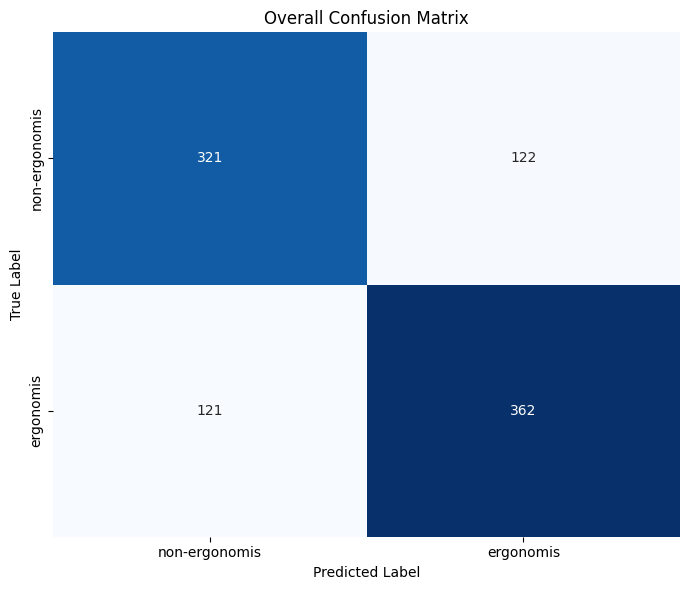

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels for readability, matching the actual two classes (0 and 1) in label_mapping
# As per label_mapping: {'ergonomis': 1, 'non-ergonomis': 0}
# So, class 0 is 'non-ergonomis' and class 1 is 'ergonomis'
class_labels = ['non-ergonomis', 'ergonomis']

print("\n" + "="*70)
print("📊 OVERALL EVALUATION METRICS (LOPO)")
print("="*70)

# 1. Overall Accuracy
overall_accuracy = accuracy_score(all_y_true, all_y_pred)
print(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)\n")

# 2. Overall Classification Report (Precision, Recall, F1-score)
print("Overall Classification Report:")
# Ensure classification_report expects only the classes present (0 and 1)
print(classification_report(all_y_true, all_y_pred, target_names=class_labels, labels=[0, 1]))

# 3. Overall Confusion Matrix
# Ensure confusion_matrix expects only the classes present (0 and 1)
overall_cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1])

print("\nOverall Confusion Matrix (True vs Predicted):")
print("          Non-Ergonomis   Ergonomis")
print(f"Non-Ergonomis     {overall_cm[0,0]:5d}   {overall_cm[0,1]:5d}")
print(f"Ergonomis         {overall_cm[1,0]:5d}   {overall_cm[1,1]:5d}")

# 4. Visualize Overall Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Overall Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Analisis Feature Importance


=== SELURUH FEATURE IMPORTANCE (diurutkan) ===
1. az2_max: 0.108698
2. az1_mean: 0.105326
3. ax1_mean: 0.089245
4. ay2_max: 0.064090
5. az2_mean: 0.059421
6. ay2_mean: 0.055970
7. az2_min: 0.055854
8. ax1_min: 0.050952
9. ax2_mean: 0.043637
10. ay1_max: 0.041478
11. ay2_min: 0.039064
12. az1_min: 0.034419
13. az1_max: 0.033128
14. ay1_min: 0.028664
15. ax1_std: 0.025853
16. ax1_max: 0.025220
17. ay1_std: 0.024704
18. ay1_mean: 0.022665
19. az1_std: 0.020505
20. ax2_min: 0.018437
21. ay2_std: 0.017791
22. ax2_max: 0.012836
23. az2_std: 0.011533
24. ax2_std: 0.010510

=== DataFrame Feature Importance (10 teratas) ===
     feature  importance
23   az2_max    0.108698
8   az1_mean    0.105326
0   ax1_mean    0.089245
19   ay2_max    0.064090
20  az2_mean    0.059421
16  ay2_mean    0.055970
22   az2_min    0.055854
2    ax1_min    0.050952
12  ax2_mean    0.043637
7    ay1_max    0.041478

Total fitur: 24


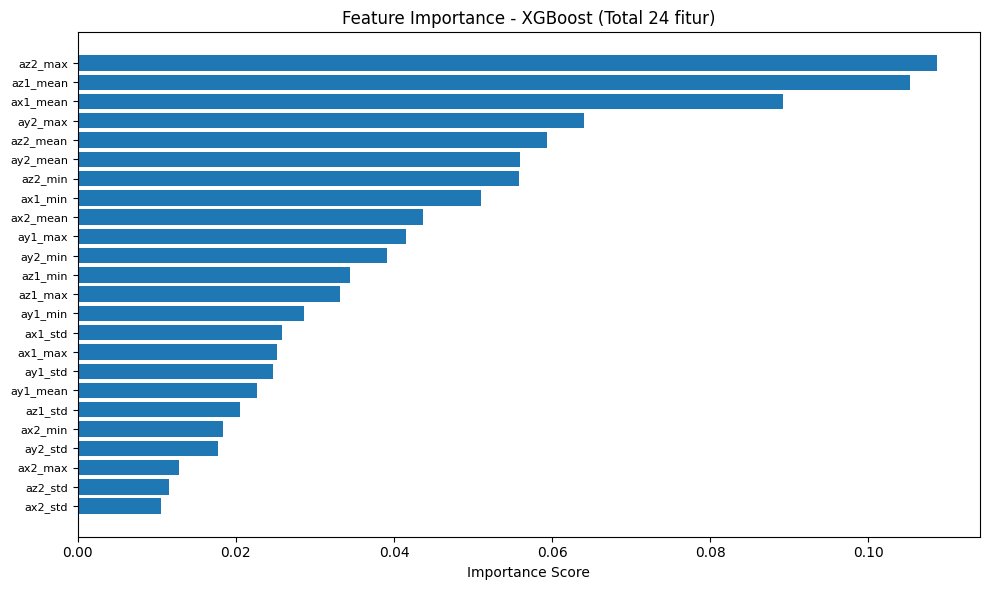

In [26]:
importances = xgb_final_model.feature_importances_
feature_names = X_train_last_fold_for_features.columns # Get column names from the DataFrame

# Urutkan berdasarkan importance descending
indices = np.argsort(importances)[::-1]

# ============================================
# OPSI 1: Tampilkan seluruh fitur dalam bentuk teks (print)
# ============================================
print("\n=== SELURUH FEATURE IMPORTANCE (diurutkan) ===")
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.6f}")

# ============================================
# OPSI 2: Simpan ke DataFrame untuk dilihat lebih mudah
# ============================
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n=== DataFrame Feature Importance (10 teratas) ===")
print(importance_df.head(10))
print(f"\nTotal fitur: {len(importance_df)}")

# ============================================
# OPSI 3: Visualisasi SEMUA fitur (HATI-HATI jika fitur > 50)
# ============================
n_features = len(feature_names)
if n_features <= 50:
    # Ukuran figure disesuaikan dengan jumlah fitur (setiap fitur ~0.2 inch)
    plt.figure(figsize=(10, max(6, n_features * 0.2)))
    plt.barh(range(n_features), importances[indices], align='center')
    plt.yticks(range(n_features), [feature_names[i] for i in indices], fontsize=8)
    plt.xlabel('Importance Score')
    plt.title(f'Feature Importance - XGBoost (Total {n_features} fitur)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"\nJumlah fitur terlalu banyak ({n_features}) untuk divisualisasikan dalam satu plot.")
    print("Gunakan 'importance_df' untuk melihat nilai importance secara detail.")


📊 VISUALISASI CONFUSION MATRIX PER SUBJECT (HEATMAP)


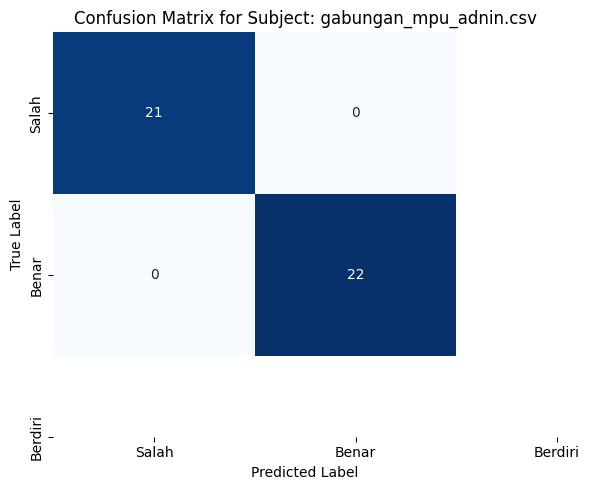

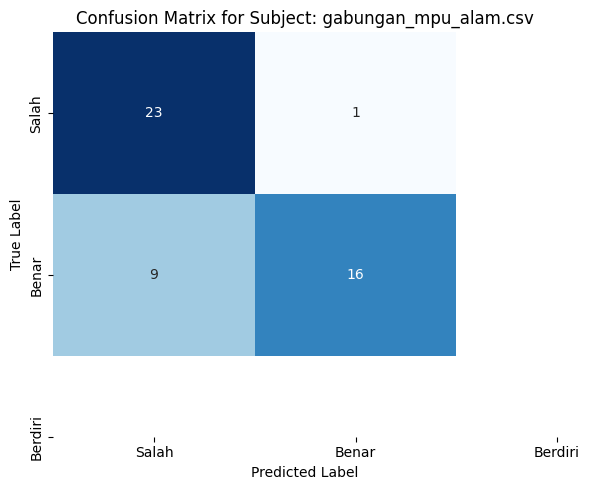

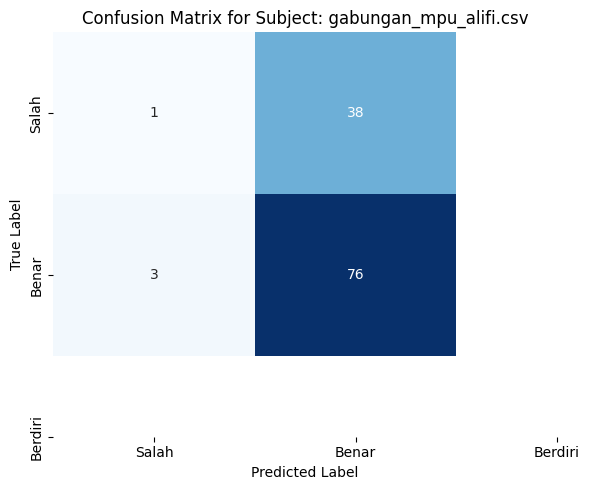

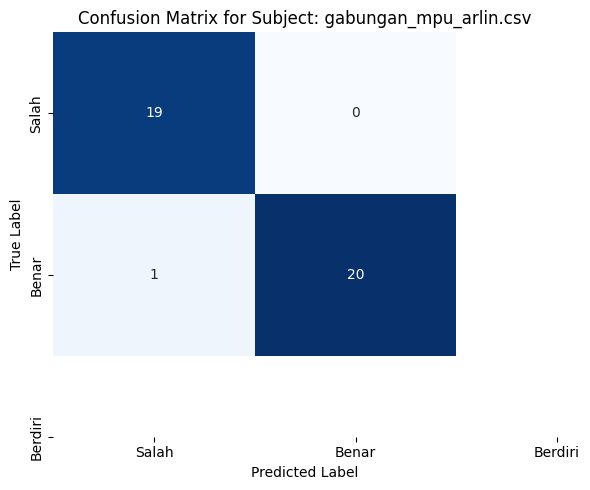

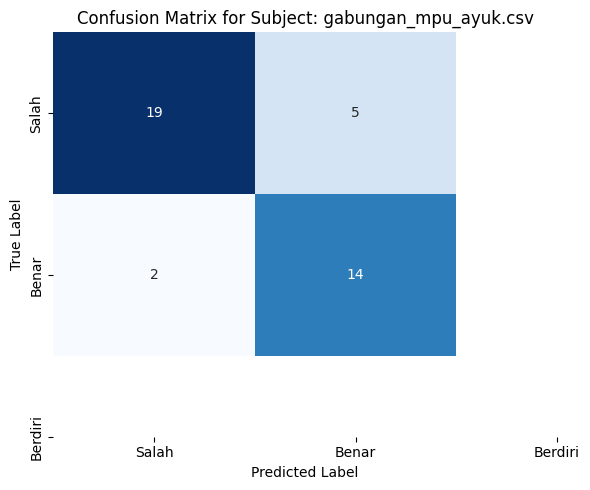

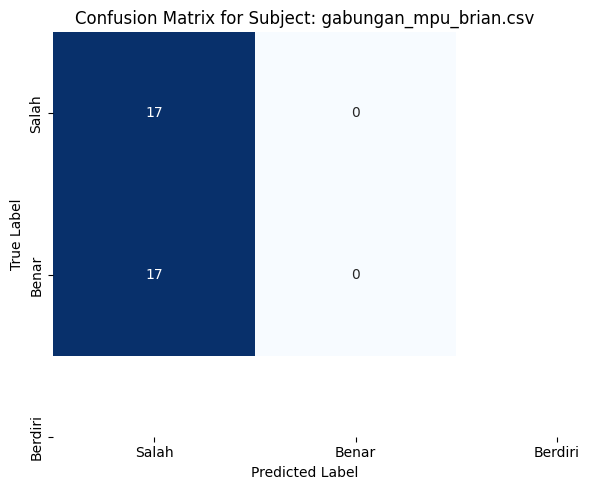

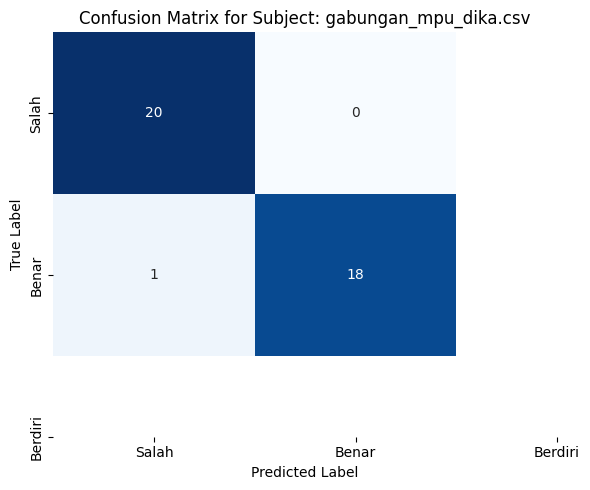

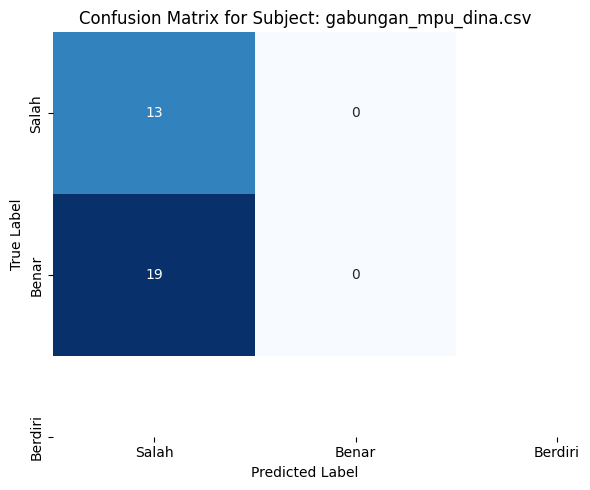

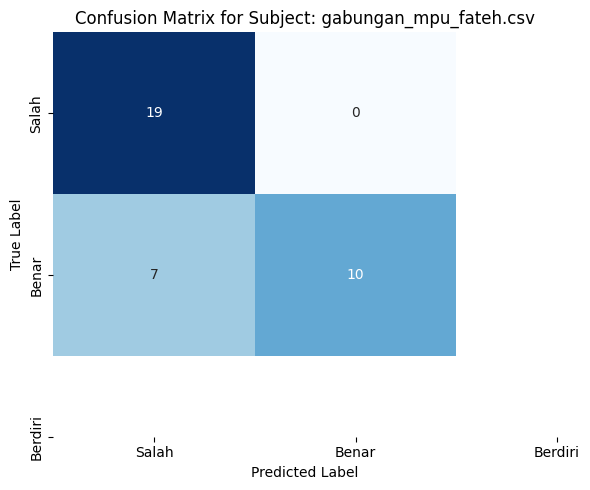

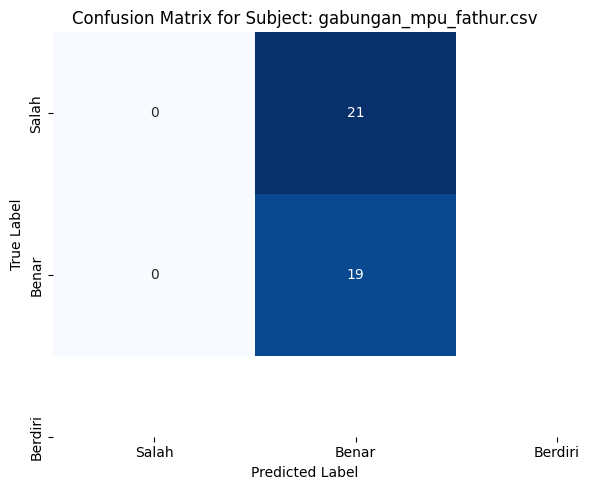

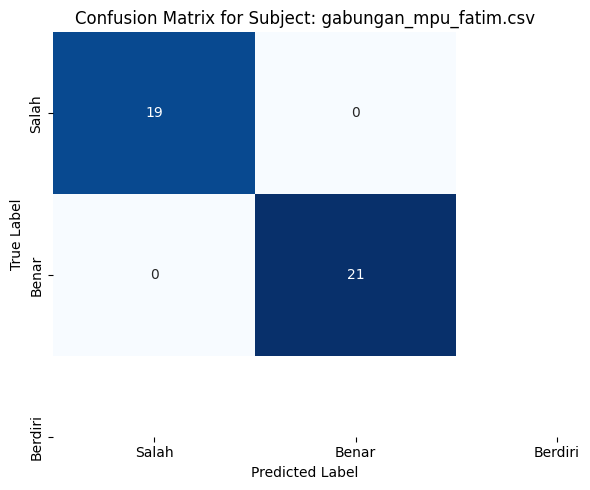

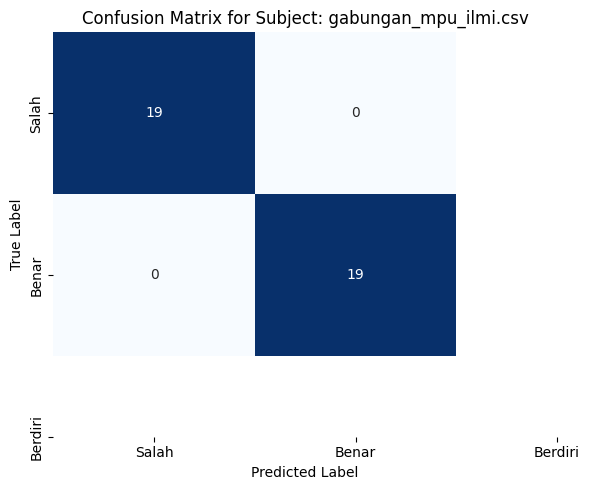

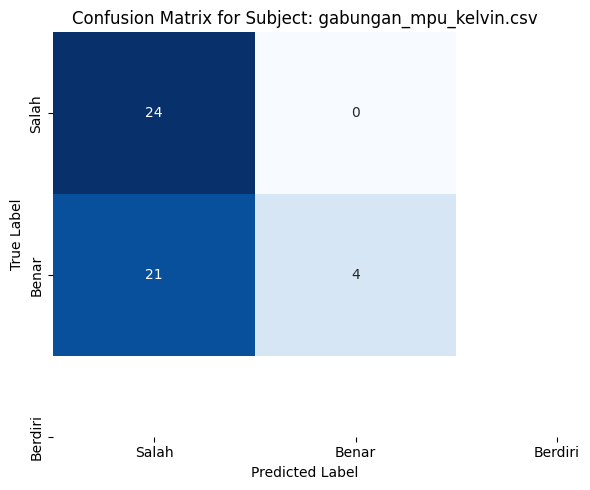

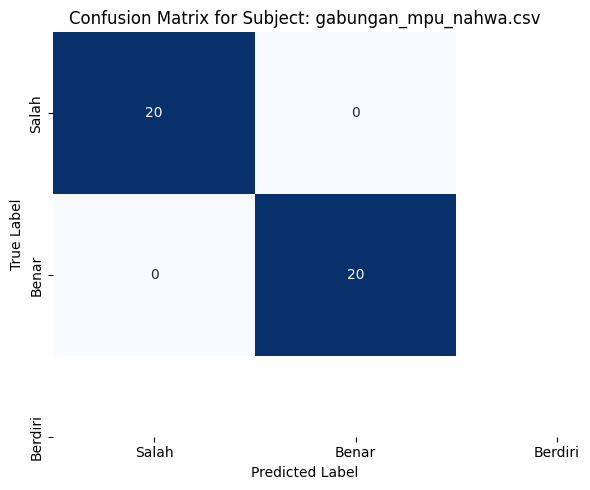

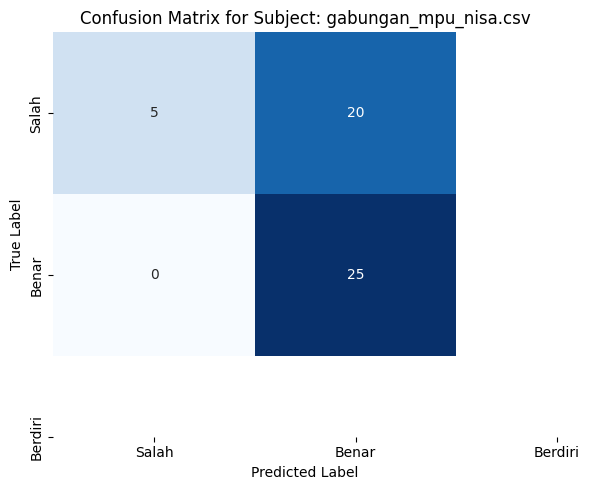

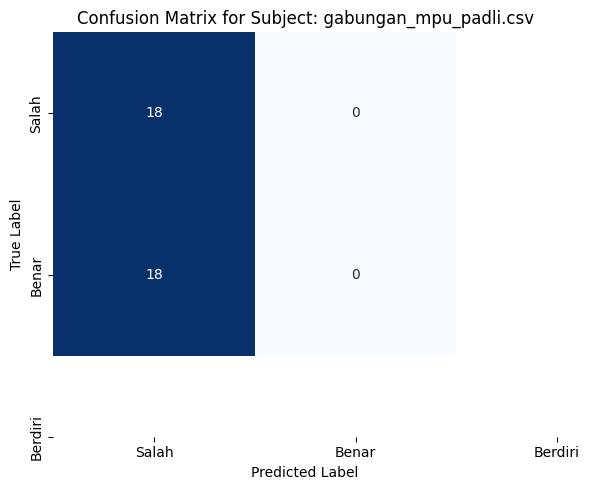

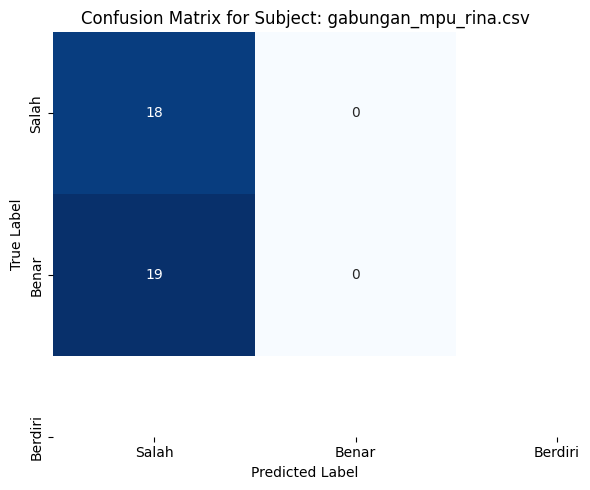

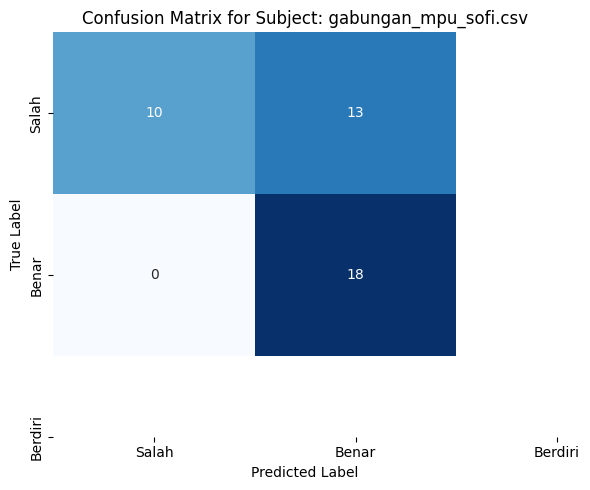

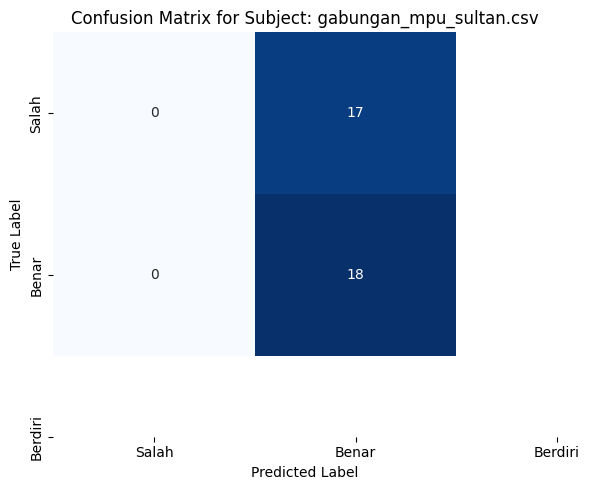

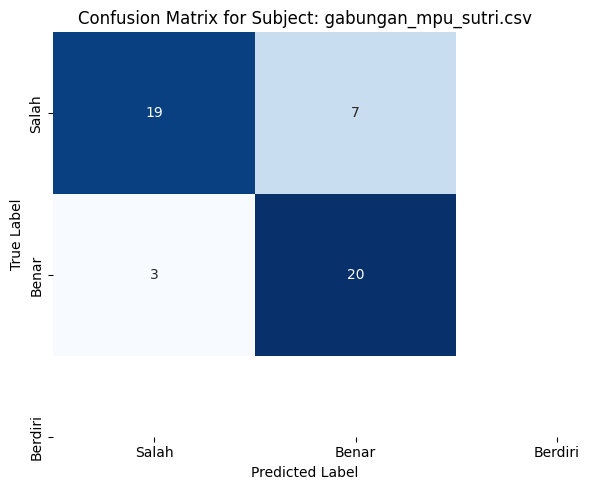

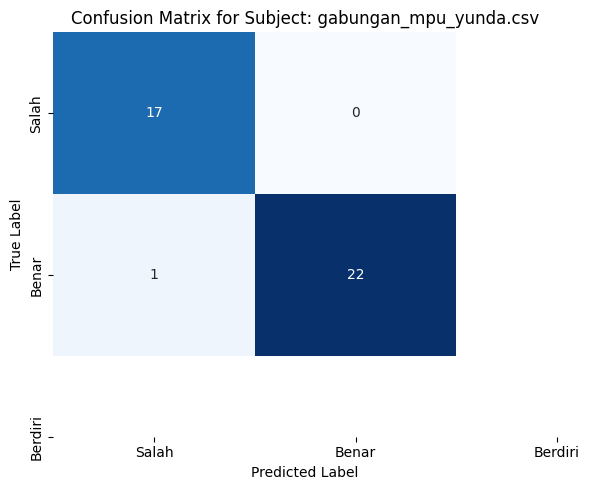

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the class labels
class_labels = ['Salah', 'Benar', 'Berdiri']

print("\n" + "="*70)
print("📊 VISUALISASI CONFUSION MATRIX PER SUBJECT (HEATMAP)")
print("="*70)

# Iterate through each subject's confusion matrix and visualize it
for subject, cm in conf_matrices.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix for Subject: {subject}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()



=== SELURUH FEATURE IMPORTANCE (diurutkan) ===
1. az2_max: 0.108698
2. az1_mean: 0.105326
3. ax1_mean: 0.089245
4. ay2_max: 0.064090
5. az2_mean: 0.059421
6. ay2_mean: 0.055970
7. az2_min: 0.055854
8. ax1_min: 0.050952
9. ax2_mean: 0.043637
10. ay1_max: 0.041478
11. ay2_min: 0.039064
12. az1_min: 0.034419
13. az1_max: 0.033128
14. ay1_min: 0.028664
15. ax1_std: 0.025853
16. ax1_max: 0.025220
17. ay1_std: 0.024704
18. ay1_mean: 0.022665
19. az1_std: 0.020505
20. ax2_min: 0.018437
21. ay2_std: 0.017791
22. ax2_max: 0.012836
23. az2_std: 0.011533
24. ax2_std: 0.010510

=== DataFrame Feature Importance (10 teratas) ===
     feature  importance
23   az2_max    0.108698
8   az1_mean    0.105326
0   ax1_mean    0.089245
19   ay2_max    0.064090
20  az2_mean    0.059421
16  ay2_mean    0.055970
22   az2_min    0.055854
2    ax1_min    0.050952
12  ax2_mean    0.043637
7    ay1_max    0.041478

Total fitur: 24


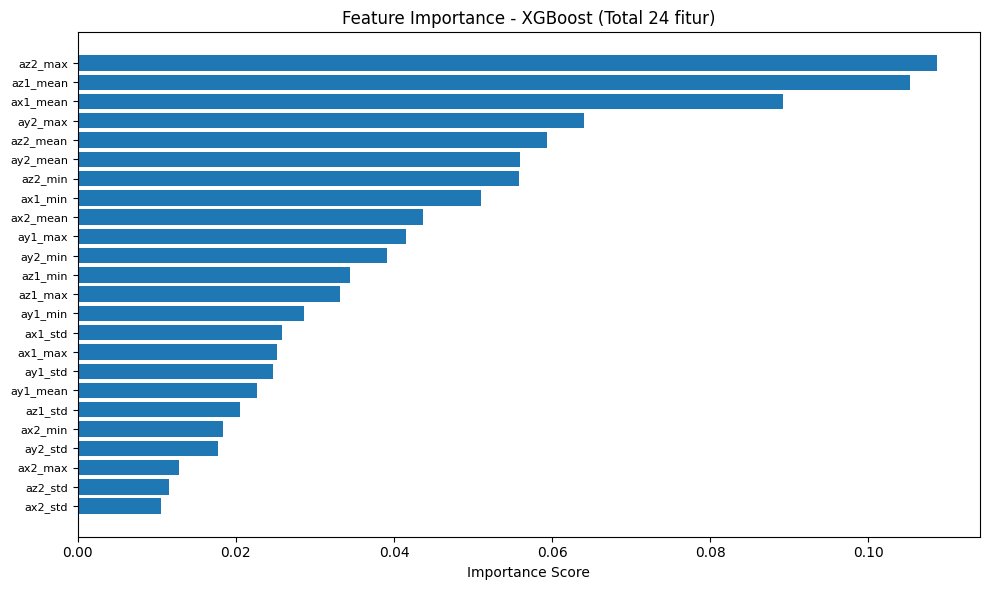

In [28]:
importances = xgb_final_model.feature_importances_
feature_names = X_train_last_fold_for_features.columns # Get column names from the DataFrame

# Urutkan berdasarkan importance descending
indices = np.argsort(importances)[::-1]

# ============================================
# OPSI 1: Tampilkan seluruh fitur dalam bentuk teks (print)
# ============================================
print("\n=== SELURUH FEATURE IMPORTANCE (diurutkan) ===")
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.6f}")

# ============================================
# OPSI 2: Simpan ke DataFrame untuk dilihat lebih mudah
# ============================
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n=== DataFrame Feature Importance (10 teratas) ===")
print(importance_df.head(10))
print(f"\nTotal fitur: {len(importance_df)}")

# ============================================
# OPSI 3: Visualisasi SEMUA fitur (HATI-HATI jika fitur > 50)
# ============================
n_features = len(feature_names)
if n_features <= 50:
    # Ukuran figure disesuaikan dengan jumlah fitur (setiap fitur ~0.2 inch)
    plt.figure(figsize=(10, max(6, n_features * 0.2)))
    plt.barh(range(n_features), importances[indices], align='center')
    plt.yticks(range(n_features), [feature_names[i] for i in indices], fontsize=8)
    plt.xlabel('Importance Score')
    plt.title(f'Feature Importance - XGBoost (Total {n_features} fitur)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"\nJumlah fitur terlalu banyak ({n_features}) untuk divisualisasikan dalam satu plot.")
    print("Gunakan 'importance_df' untuk melihat nilai importance secara detail.")


## Analisis

In [29]:
print(results_df.to_string(index=False))
print(f"\nRata-rata: {results_df['accuracy'].mean():.4f}")
print(f"Std Dev  : {results_df['accuracy'].std():.4f}")

# === CEK 2: Classification report per kelas ===
from sklearn.metrics import classification_report
print("\n", classification_report(
    all_y_true, all_y_pred,
    target_names=['non-ergonomis', 'ergonomis']
))

# === CEK 3: Frekuensi sampling ===
print(f"\nsampling_freq = {sampling_freq:.4f} Hz")

# === CEK 4: Distribusi kelas per subjek ===
print("\nDistribusi label per subjek:")
print(df_clean.groupby(['source_file','label'])['label'].count().unstack(fill_value=0))

# === CEK 5: Jumlah windows per subjek ===
print("\nJumlah sampel per subjek (test):")
for r in lopo_results:
    print(f"  {r['test_subject']:<30s}: {r['n_test_samples']:>4d} samples")

 fold            test_subject  n_train_samples  n_test_samples  accuracy
    1  gabungan_mpu_adnin.csv              891              43  1.000000
    2   gabungan_mpu_alam.csv              885              49  0.795918
    3  gabungan_mpu_alifi.csv              816             118  0.652542
    4  gabungan_mpu_arlin.csv              895              40  0.975000
    5   gabungan_mpu_ayuk.csv              895              40  0.825000
    6  gabungan_mpu_brian.csv              901              34  0.500000
    7   gabungan_mpu_dika.csv              896              39  0.974359
    8   gabungan_mpu_dina.csv              902              32  0.406250
    9  gabungan_mpu_fateh.csv              898              36  0.805556
   10 gabungan_mpu_fathur.csv              895              40  0.475000
   11  gabungan_mpu_fatim.csv              894              40  1.000000
   12   gabungan_mpu_ilmi.csv              896              38  1.000000
   13 gabungan_mpu_kelvin.csv              885     

## Simpan Model dan Output

In [30]:
# Cell Model 6: Simpan model, scaler, hasil evaluasi, dan info penggunaan model
import joblib
import json
import os
import pandas as pd # Import pandas for DataFrame creation

# ========== ATUR PATH PENYIMPANAN DI SINI ==========
SAVE_DIR = '/content/drive/MyDrive/Dataset Skripsi /OutputColabAnisa'
# ==================================================

# Buat folder jika belum ada
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================
# Simpan model dan scaler
# ==========================
joblib.dump(
    xgb_final_model,
    os.path.join(
        SAVE_DIR,
        'xgboost_model.pkl' # Changed to xgboost_model.pkl
    )
)

joblib.dump(
    scaler_hp,
    os.path.join(
        SAVE_DIR,
        'scaler.pkl'
    )
)

print(
    f"Model dan scaler disimpan di: {SAVE_DIR}"
)

# ==========================
# Simpan classification report
# ==========================
report = classification_report(
    all_y_true, # Use all_y_true
    all_y_pred, # Use all_y_pred
    target_names=[
        'non-ergonomis',
        'ergonomis'
    ],
    output_dict=True
)

with open(
    os.path.join(
        SAVE_DIR,
        'classification_report.json'
    ),
    'w'
) as f:
    json.dump(
        report,
        f,
        indent=4
    )

print(
    f"Classification report disimpan ke: "
    f"{SAVE_DIR}/classification_report.json"
)

# ==========================
# Simpan prediksi ke CSV
# ==========================
# Create a DataFrame from the aggregated true and predicted labels
hasil_prediksi = pd.DataFrame({
    'true_label': all_y_true,
    'predicted_label': all_y_pred
})

hasil_prediksi.to_csv(
    os.path.join(
        SAVE_DIR,
        'predictions.csv'
    ),
    index=False
)

print(
    f"Hasil prediksi disimpan ke: "
    f"{SAVE_DIR}/predictions.csv"
)

# ==========================
# Simpan informasi model ke TXT
# ==========================

info_model = f"""
INFORMASI MODEL XGBOOST
=============================

Nama Model:
xgboost_model.pkl

Scaler:
scaler.pkl

Jenis Model:
XGBoost Classifier

INPUT YANG DIPERLUKAN
---------------------
Model membutuhkan input berikut:

{list(feature_names_hp)}

Jumlah fitur:
{len(feature_names_hp)}

Catatan:
- Urutan input HARUS sama seperti daftar fitur di atas
- Data input harus melalui proses scaling
  menggunakan scaler.pkl sebelum prediksi
- Format input disarankan:
  DataFrame pandas atau array numerik

CONTOH ALUR PENGGUNAAN
---------------------

1. Load model:
   xgb_model = joblib.load(
       'xgboost_model.pkl'
   )

2. Load scaler:
   scaler = joblib.load(
       'scaler.pkl'
   )

3. Masukkan data baru

4. Lakukan scaling:
   data_scaled = scaler.transform(
       data_baru
   )

5. Prediksi:
   hasil = xgb_model.predict(
       data_scaled
   )

OUTPUT YANG DIHASILKAN
----------------------

0 = non-ergonomis
1 = ergonomis

Interpretasi:
- Output model berupa kelas numerik
- Gunakan mapping di atas
  untuk membaca hasil prediksi

File dibuat otomatis setelah training.
"""

with open(
    os.path.join(
        SAVE_DIR,
        'model_info.txt'
    ),
    'w',
    encoding='utf-8'
) as f:
    f.write(info_model)

print(
    f"Informasi model disimpan ke: "
    f"{SAVE_DIR}/model_info.txt"
)

Model dan scaler disimpan di: /content/drive/MyDrive/Dataset Skripsi /OutputColabAnisa
Classification report disimpan ke: /content/drive/MyDrive/Dataset Skripsi /OutputColabAnisa/classification_report.json
Hasil prediksi disimpan ke: /content/drive/MyDrive/Dataset Skripsi /OutputColabAnisa/predictions.csv
Informasi model disimpan ke: /content/drive/MyDrive/Dataset Skripsi /OutputColabAnisa/model_info.txt


In [31]:
adlkfn

NameError: name 'adlkfn' is not defined

# Hyperparameter

In [ ]:
# =============================================================================
# GRID SEARCH HANYA UNTUK SUBJEK DENGAN AKURASI TERENDAH
# =============================================================================

import numpy as np
import pandas as pd
import xgboost as xgb
import joblib
import json
import os
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm
import math

# -----------------------------------------------------------------------------
# 1. Identifikasi subjek dengan akurasi terendah dari hasil LOPO sebelumnya
# -----------------------------------------------------------------------------
if 'lopo_results' not in globals() or len(lopo_results) == 0:
    raise RuntimeError("lopo_results tidak ditemukan. Jalankan kode LOPO awal terlebih dahulu.")

df_results = pd.DataFrame(lopo_results)
worst_subject = df_results.loc[df_results['accuracy'].idxmin(), 'test_subject']
worst_accuracy = df_results['accuracy'].min()
print(f"Subjek dengan akurasi terendah: {worst_subject} (akurasi = {worst_accuracy:.4f})")
print(f"Melakukan grid search pada data train (tanpa subjek ini) untuk mencari parameter terbaik.\n")

# -----------------------------------------------------------------------------
# 2. Siapkan data untuk fold subjek terendah (train = semua kecuali subjek tsb)
# -----------------------------------------------------------------------------
WINDOW_SIZE = 30  # Sesuaikan dengan yang digunakan sebelumnya

# Split data
train_mask = groups != worst_subject
test_mask  = groups == worst_subject

X_train_current = X[train_mask].reset_index(drop=True)
y_train_current = y[train_mask].reset_index(drop=True)
X_test_current  = X[test_mask].reset_index(drop=True)
y_test_current  = y[test_mask].reset_index(drop=True)

if len(X_train_current) == 0 or len(X_test_current) == 0:
    raise RuntimeError(f"Data kosong untuk subjek {worst_subject}")

# Windowing
X_train_w, y_train_w = create_windowed_features(
    X_train_current, y_train_current, window_size=WINDOW_SIZE, step_size=WINDOW_SIZE
)
X_test_w, y_test_w = create_windowed_features(
    X_test_current, y_test_current, window_size=WINDOW_SIZE, step_size=WINDOW_SIZE
)

if len(X_train_w) == 0 or len(X_test_w) == 0:
    raise RuntimeError(f"Windowing menghasilkan data kosong untuk subjek {worst_subject}")

print(f"Jumlah window train: {len(y_train_w)}, test: {len(y_test_w)}")

# Scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_w)
X_test_scaled  = scaler.transform(X_test_w)

# -----------------------------------------------------------------------------
# 3. Parameter grid (bisa disesuaikan)
# -----------------------------------------------------------------------------
param_grid = {
    'n_estimators': [200, 250, 300],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.008, 0.009, 0.01, 0.012, 0.015],
    'subsample': [0.5, 0.6, 0.7, 0.8],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0.3, 0.4, 0.5, 0.6],
    'min_child_weight': [1, 2, 3],
    'reg_alpha': [0.5, 1, 1.5, 2],
    'reg_lambda': [5, 7, 10, 12, 15],
}

# Reduksi jika total kombinasi > 500
total_combos = np.prod([len(v) for v in param_grid.values()])
MAX_COMBOS = 25000
if total_combos > MAX_COMBOS:
    print(f"Total kombinasi {total_combos} > {MAX_COMBOS}, melakukan reduksi...")
    new_grid = {}
    target_per_param = math.exp(math.log(MAX_COMBOS) / len(param_grid))
    for key, values in param_grid.items():
        n_take = max(2, int(len(values) * (target_per_param / (total_combos ** (1/len(param_grid))))))
        indices = np.linspace(0, len(values)-1, n_take, dtype=int)
        new_grid[key] = [values[i] for i in indices]
    param_grid = new_grid
    total_combos = np.prod([len(v) for v in param_grid.values()])
print(f"Total kombinasi grid akhir: {total_combos}")

# -----------------------------------------------------------------------------
# 4. Grid search dengan cross-validation 5-fold (scoring = f1)
# -----------------------------------------------------------------------------
param_list = list(ParameterGrid(param_grid))
best_score = -np.inf
best_params = None
best_model = None

total_fits = len(param_list) * 5
print(f"Memulai grid search dengan {len(param_list)} kombinasi, CV=5 -> total {total_fits} fit...")

with tqdm(total=total_fits, desc="Grid search progress", unit="fit") as pbar:
    for params in param_list:
        model = xgb.XGBClassifier(
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss',
            **params
        )
        cv_scores = cross_val_score(model, X_train_scaled, y_train_w, cv=5, scoring='f1')
        mean_score = np.mean(cv_scores)
        pbar.update(5)

        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            best_model = xgb.XGBClassifier(
                random_state=42, n_jobs=-1, eval_metric='logloss', **params
            )
            best_model.fit(X_train_scaled, y_train_w)
            pbar.set_postfix(current_best=f"{best_score:.4f}")

print("\n" + "="*50)
print("HASIL GRID SEARCH PADA SUBJEK TERENDAH")
print("="*50)
print(f"Subjek target (test): {worst_subject}")
print(f"Parameter terbaik (berdasarkan F1 CV): {best_params}")
print(f"F1 score rata-rata CV: {best_score:.4f}")

# -----------------------------------------------------------------------------
# 5. Evaluasi pada test set subjek tersebut (opsional)
# -----------------------------------------------------------------------------
y_pred = best_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test_w, y_pred)
test_f1 = f1_score(y_test_w, y_pred)
print(f"\nEvaluasi pada test set subjek {worst_subject}:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  F1-score: {test_f1:.4f}")

# -----------------------------------------------------------------------------
# 6. Simpan parameter terbaik dan model
# -----------------------------------------------------------------------------
SAVE_DIR = '/content/drive/MyDrive/Dataset Skripsi /OutputColab'
os.makedirs(SAVE_DIR, exist_ok=True)

# Simpan parameter
with open(os.path.join(SAVE_DIR, 'best_params_worst_subject.json'), 'w') as f:
    json.dump(best_params, f, indent=4)

# Simpan model
joblib.dump(best_model, os.path.join(SAVE_DIR, 'xgboost_worst_subject_tuned.pkl'))

# Simpan scaler dan feature names untuk referensi
joblib.dump(scaler, os.path.join(SAVE_DIR, 'scaler_worst_subject.pkl'))
pd.DataFrame(X_train_w.columns).to_csv(os.path.join(SAVE_DIR, 'feature_names_worst_subject.csv'), index=False)

print(f"\nParameter dan model disimpan di: {SAVE_DIR}")
print("\nSekarang Anda dapat menggunakan parameter tersebut untuk melatih model pada seluruh data atau untuk semua subject.")